# Modelling inflationary impact of the ETS in the EU
This notebook models the impact of carbon price increases on inflation in different EU countries. 

@author: florian wirth 2026


## Loading Figaro IO tables
First, we have to load the Figaro database.

In [109]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from matplotlib.colors import LogNorm
from adjustText import adjust_text
import eurostat
from itertools import product
import logging
import warnings
import country_converter as coco   

# Add local directory to sys.path via relative path
from mrio_toolbox import MRIO, Part, multi_scale_mapping

# Suppress warnings about duplicate dimension names specific UserWarnings from xarray.namedarray
logging.getLogger("mrio_toolbox._parts._Part").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning, module=r"xarray\.namedarray\.core")


############################
# Set script-wide parameters
############################

year = 2024  # Set the year for the analysis
country_coverage = "eu27" 
emission_coverage = "ets2" # coverage options: "ets1", "ets2" "ets1and2", "all" (for all emissions)

#price_scenario = "uniform-53-euros"
#price_scenario = "ets2-ec"
price_scenario = "ets2-strong"
#price_scenario = "ets2-weak"

figure_path = f"../figures/{price_scenario}_{year}_{emission_coverage}_{country_coverage}/"
# Create the figure path if it doesn't exist
os.makedirs(figure_path, exist_ok=True)

# load figaro
figaro_file_path = os.path.abspath(f"../data/figaro io/formatted io/figaro_year{year}_aggregated_{country_coverage}.nc")
figaro = MRIO(file= figaro_file_path)
countries = figaro.labels["countries"]
sectors = figaro.labels["sectors"]

## Check table balance

In [110]:
T = figaro.t # inter industry transactions
Y = figaro.y # final demand
V = figaro.va# value added
S = figaro.sup # supply table
M = T["ROW", "all"] # imports are defined as all T matrix entries with ROW on the vertical axis
E = T["all", "ROW"] # exports are defined as all T matrix entries with ROW on the horizontal axis

# Transform units from million euros to euros. WARNING: Don't run this cell multiple times, otherwise the values will be scaled up by 1e6 each time.
T = T * 1e6
Y = Y * 1e6
V = V * 1e6
S = S * 1e6
M = M * 1e6
E = E * 1e6

# before removing ROW
x_t1 = T.sum(axis = 0) + V.sum(axis = 0)
x_t2 = T.sum(axis = 1) + Y.sum(axis = 1)
x_s = S.sum(axis = 0)

print("First balance: iT + iV = (Ti + Yi)'")
print((x_t1 - x_t2).to_pandas().describe())
print()
print("Second balance: iS = iT + iV")
print((x_s - x_t1).to_pandas().describe())
print()

# Exclude ROW 
if "ROW" in countries:
    countries.remove("ROW") 

T = T[[[countries], "all"], [[countries], "all"]]
Y = Y[[countries], "all"]
V = V["all", [countries, "all"]]
S = S[[[countries], "all"], [[countries], "all"]]
M = M["all", [countries]]
E = E[[countries], "all"]

# after removing ROW
x_t1 = T.sum(axis = 0) + V.sum(axis = 0) + M.sum(axis = 0) # remove inter-industry ROW trade by selecting only countries other than ROW
x_t2 = T.sum(axis = 1) + Y.sum(axis = 1) + E.sum(axis = 1) # remove inter-industry ROW trade by selecting only countries other than ROW
x_s = S.sum(axis = 0)

print("First balance after ROW removal: iT + iV = (Ti + Yi)'")
print((x_t1 - x_t2).to_pandas().describe())
print()
print("Second balance after ROW removal: iS = iT + iV")
print((x_s - x_t1).to_pandas().describe())

# take any gross output computation as X
X = x_t1

First balance: iT + iV = (Ti + Yi)'
                  0
count  1.792000e+03
mean  -1.044433e-07
std    6.642100e-05
min   -9.765625e-04
25%    0.000000e+00
50%    0.000000e+00
75%    0.000000e+00
max    1.953125e-03

Second balance: iS = iT + iV
                  0
count  1.792000e+03
mean   1.044191e+05
std    2.466766e+05
min   -1.900000e+04
25%    3.600000e+04
50%    5.900000e+04
75%    8.800000e+04
max    2.000000e+06

First balance after ROW removal: iT + iV = (Ti + Yi)'
                  0
count  1.728000e+03
mean  -2.485952e-09
std    2.658842e-07
min   -7.629395e-06
25%    0.000000e+00
50%    0.000000e+00
75%    0.000000e+00
max    7.629395e-06

Second balance after ROW removal: iS = iT + iV
                   0
count    1728.000000
mean    59636.574074
std     33303.553496
min    -19000.000000
25%     35000.000000
50%     57500.000000
75%     84250.000000
max    148000.000000


We see that on absolute terms, the tables are balanced and that the balance also holds when removing ROW. The maximum absolute imbalance after removing ROW is 148 000 €, which is still small compared to Malta's GDP of 23 billion € in 2024. 

In [111]:
names = [f"{c} + {s}" for c, s in  product(x_s.labels["countries"], x_s.labels["sectors"])]
diff = x_s.data - X.data
relative_diff = diff / X.data * 100  # Calculate relative difference in percent
balancing_df = pd.DataFrame({"names": names, "diff": diff, "relative diff": relative_diff, "x_t": X.data, "x_s": x_s.data})
average_relative_diff = balancing_df["relative diff"].mean()
print(f"The average relative difference between the supply and IO table gross output is {average_relative_diff:.4f} percent")
print(f"The median relative difference between the supply and IO table gross output is {balancing_df['relative diff'].median():.4f} percent")
print(f"The maximum relative difference between the supply and IO table gross output is {balancing_df['relative diff'].max():.4f} percent")

balancing_df.sort_values(by="relative diff", ascending=False, inplace=True)
balancing_df

The average relative difference between the supply and IO table gross output is 0.0192 percent
The median relative difference between the supply and IO table gross output is 0.0012 percent
The maximum relative difference between the supply and IO table gross output is 3.8123 percent


/tmp/ipykernel_42492/977494326.py:3: RuntimeWarning: invalid value encountered in divide
  relative_diff = diff / X.data * 100  # Calculate relative difference in percent


,names,diff,relative diff,x_t,x_s
1161,LV + Manufacture of coke and refined petroleum...,26000.0,3.812317,682000.0,708000.0
1609,SI + Manufacture of coke and refined petroleum...,44000.0,2.064758,2131000.0,2175000.0
1236,MT + Manufacture of other transport equipment,25000.0,1.141031,2191000.0,2216000.0
1222,MT + Manufacture of wood and of products of wo...,99000.0,0.807702,12257000.0,12356000.0
1602,SI + Fishing and aquaculture,111000.0,0.688287,16127000.0,16238000.0
...,...,...,...,...,...
1534,RO + Activities of households as employers; un...,0.0,NaN,0.0,0.0
1535,RO + Activities of extraterritorial organisati...,0.0,NaN,0.0,0.0
1599,SE + Activities of extraterritorial organisati...,0.0,NaN,0.0,0.0
1663,SI + Activities of extraterritorial organisati...,0.0,NaN,0.0,0.0


We see that also in relative terms, there are no big discrepancies and the tables can be used as is. 

## Load emission coverage
Next, we compute emission intensities for the ETS1 and ETS2 based on the emission satellite accounts from the multi-scale-mapping algorithm. We start by collecting a list of covered emission categories.

Note: ets1 and ets2 have overlapping coverage, e.g. 1.A.1.a is contained in both. So if we want to disaggregate, then we should rather just use the effect of ets1 and the total effect. The difference is then the effect of ets2.

In [112]:
qt_coverage = figaro.qt.labels["Emission categories"]

ets1_coverage = pd.read_excel("../data/sectoral coverage/Emission Coverage ETS.xlsx", sheet_name="ETS1")["IPCC Source Category"].dropna().tolist()
ets1_coverage.sort()
ets1_coverage = [cat for cat in ets1_coverage if cat in qt_coverage] # remove categories that are not in qt_coverage

ets2_coverage = pd.read_excel("../data/sectoral coverage/Emission Coverage ETS.xlsx", sheet_name="ETS2")["IPCC Source Category"].dropna().tolist()
ets2_coverage.sort()
ets2_coverage = [cat for cat in ets2_coverage if cat in qt_coverage]

ets1and2_coverage = list(set(ets1_coverage).union(set(ets2_coverage)))
ets1and2_coverage.sort()

complete_coverage = []
for cat in (qt_coverage):
    if not any([cat.startswith(parent + ".") for parent in qt_coverage]):
        complete_coverage.append(cat)
#complete_coverage.remove("M.0.EL") # otherwise double counting 

Then, we load the emissions from Figaro and build different Q matrices based on the coverage

In [113]:
figaro.qt = figaro.qt * 1000 # convert from kt CO2 to t CO2
figaro.qy = figaro.qy * 1000 # convert from kt CO2 to t CO2
Q_ets1 = figaro.qt[[ets1_coverage], "all"].sum(on = "Emission categories") # Emissions covered from ETS1
Q_ets2 = figaro.qt[[ets2_coverage], "all"].sum(on = "Emission categories") # Emissions covered from ETS1 and ETS2
Q_ets1and2 = figaro.qt[[ets1and2_coverage], "all"].sum(on = "Emission categories") # Emissions covered from ETS1 and ETS2
Q_all = figaro.qt[[complete_coverage], "all"].sum(on = "Emission categories") # All CO2 emissions

Q_ets1 = Q_ets1[[countries], ]
Q_ets2 = Q_ets2[[countries], ]
Q_ets1and2 = Q_ets1and2[[countries],]
Q_all = Q_all[[countries],]

qy = figaro.qy

In [114]:
# Compute technical coefficients and shares from partitioned table without ROW
A = T / X # technical coefficients
q_ets1 = Q_ets1 / X
q_ets2 = Q_ets2 / X
q_ets1and2 = Q_ets1and2 / X
q_all = Q_all / X

# treat nans and infs
A.data = np.nan_to_num(A.data, nan=0.0)
L = A.leontief_inversion()

q_ets1.data = np.nan_to_num(q_ets1.data, nan=0.0, posinf=0.0)
q_ets2.data = np.nan_to_num(q_ets2.data, nan=0.0, posinf=0.0)
q_ets1and2.data = np.nan_to_num(q_ets1and2.data, nan=0.0, posinf=0.0)
q_all.data = np.nan_to_num(q_all.data, nan=0.0, posinf=0.0)

# define q based on coverage option. Later we can extend this in order to disaggregate and use multiple q's
match emission_coverage:
    case "ets1":
        Q = Q_ets1
        q = q_ets1
    case "ets2":
        Q = Q_ets2
        q = q_ets2
    case "ets1and2":
        Q = Q_ets1and2
        q = q_ets1and2
    case "all":
        Q = Q_all
        q = q_all
    case _:
        raise ValueError(f"Invalid coverage option: {emission_coverage}. Choose from 'ets1', 'ets1and2', or 'all'.")

/home/florian/Wissenschaft/eu-ets-inflation-impact/mrio_toolbox/mrio_toolbox/_parts/_Part.py:1724: RuntimeWarning: invalid value encountered in divide
  return self.alias(data=self.data/a,
/home/florian/Wissenschaft/eu-ets-inflation-impact/mrio_toolbox/mrio_toolbox/_parts/_Part.py:1724: RuntimeWarning: divide by zero encountered in divide
  return self.alias(data=self.data/a,


## Print emission coverage

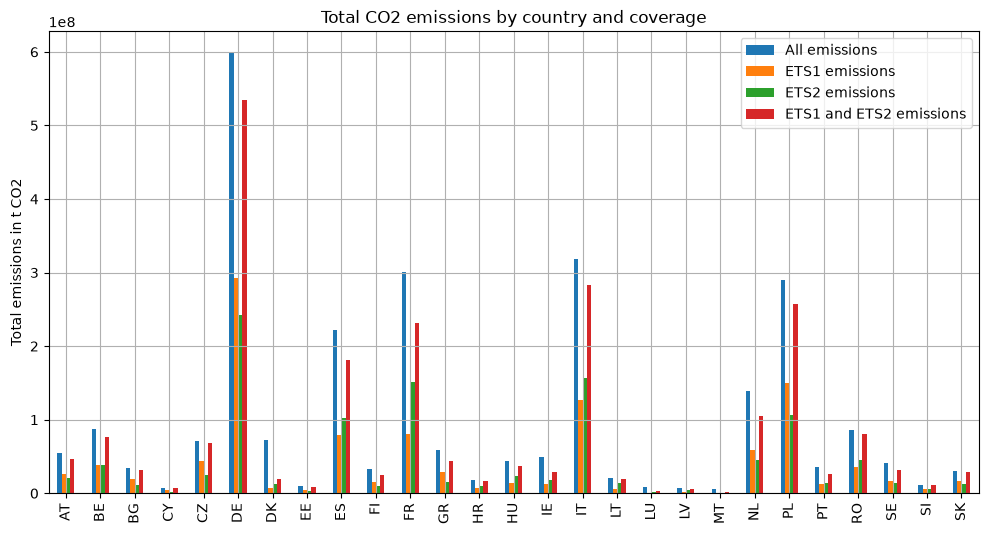

In [115]:
# Print emission coverage by country
df = pd.DataFrame(index = countries)
df["All emissions"] = Q_all.sum(on = "sectors").to_pandas() + qy.sum(on = "hh_sectors").sum(on = "Emission categories")[countries].to_pandas()
df["ETS1 emissions"] = Q_ets1.sum(on = "sectors").to_pandas()
df["ETS2 emissions"] = Q_ets2.sum(on = "sectors").to_pandas() + qy.sum(on = "hh_sectors").sum(on = "Emission categories")[countries].to_pandas()
df["ETS1 and ETS2 emissions"] = Q_ets1and2.sum(on = "sectors").to_pandas() + qy.sum(on = "hh_sectors").sum(on = "Emission categories")[countries].to_pandas()

df.plot(kind="bar", figsize=(12, 6),grid=True)
plt.ylabel("Total emissions in t CO2")
plt.title("Total CO2 emissions by country and coverage")
plt.savefig(os.path.join(figure_path, f"bar_emissions_by_country_and_coverage.png"), bbox_inches='tight', dpi=300)

## Emission contribution of each sector and country

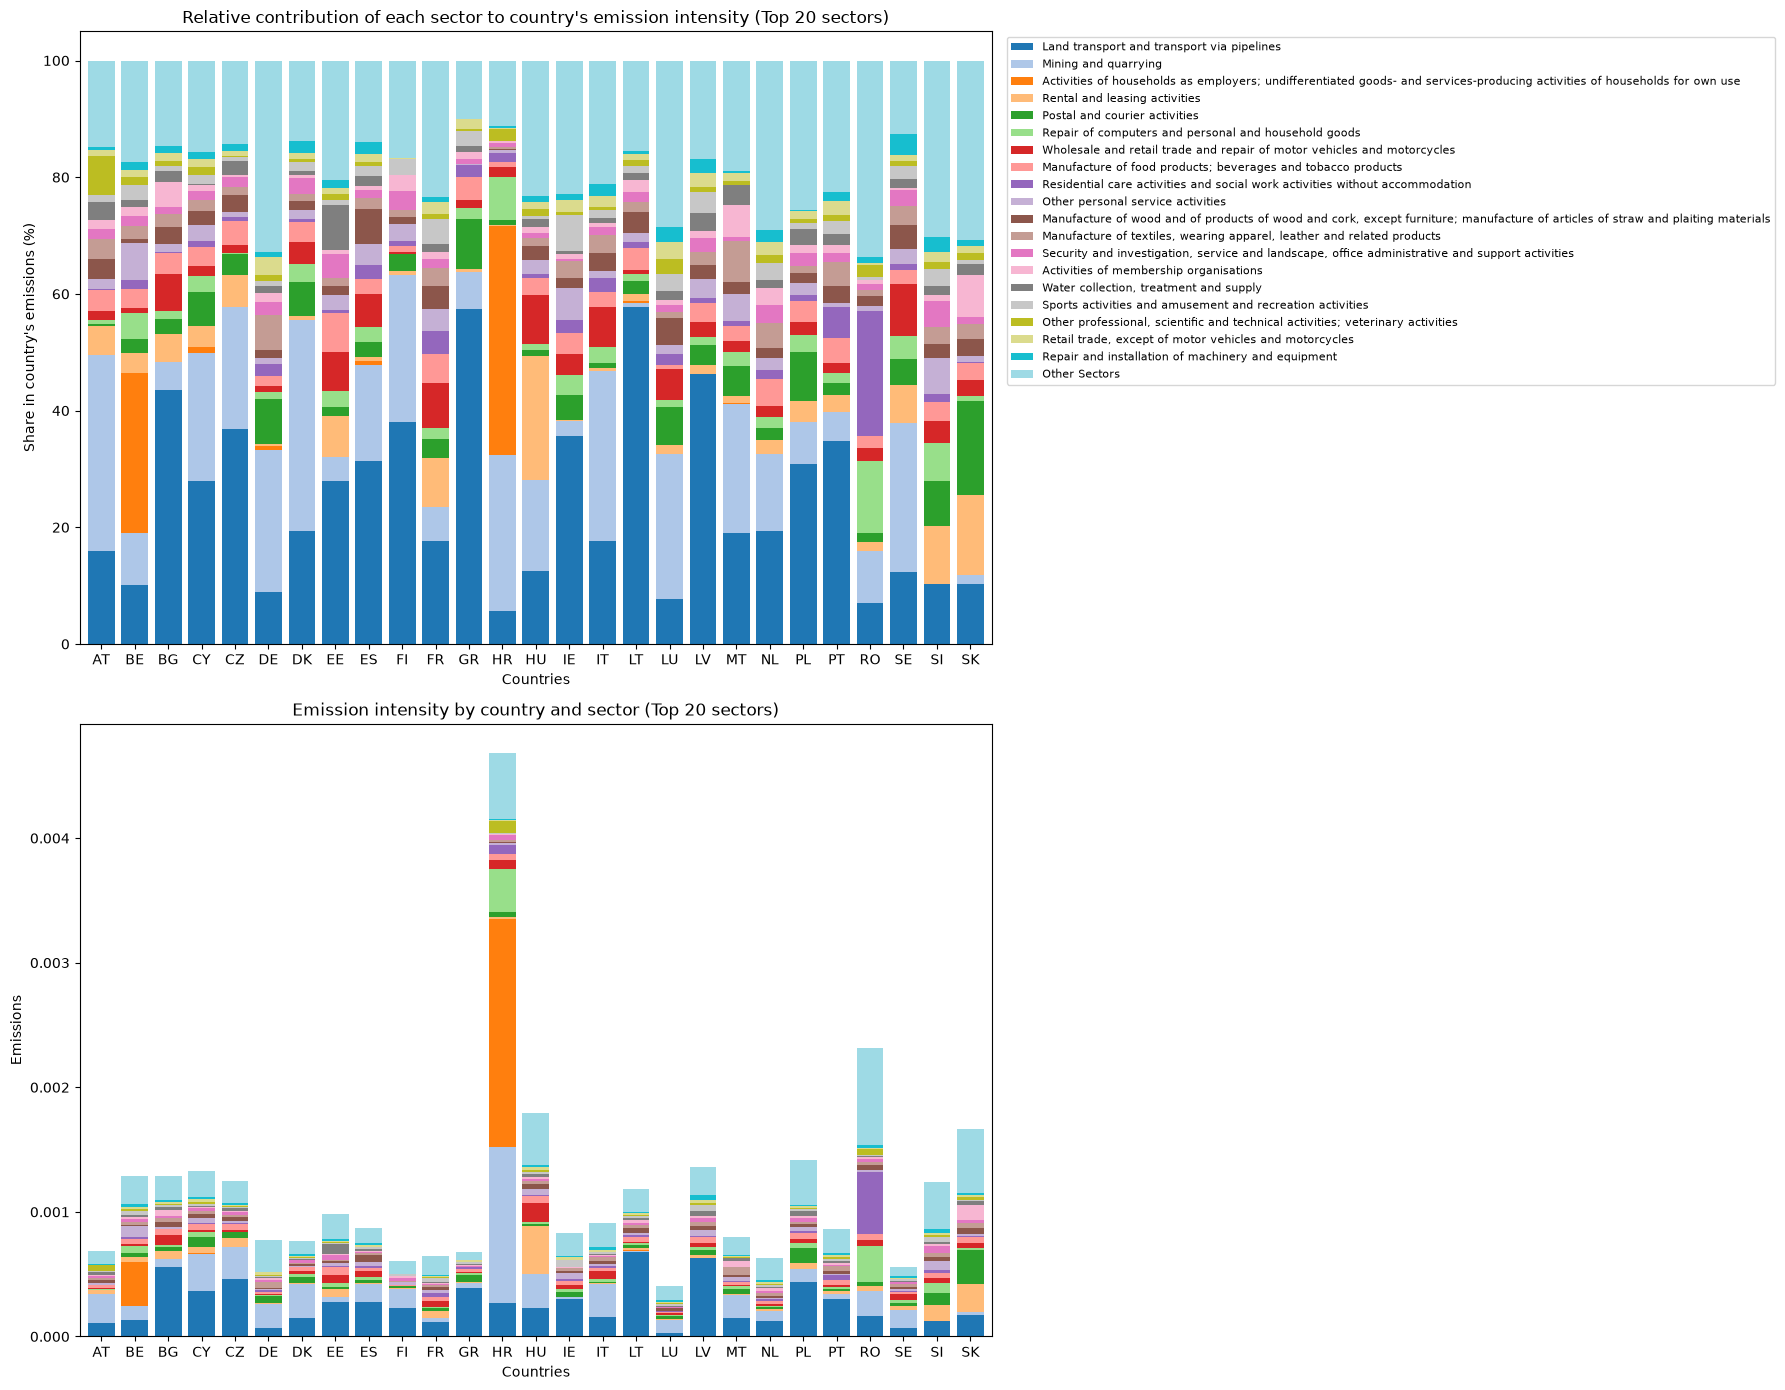

In [116]:
df = q.develop().to_pandas()

top20 = df.sum().nlargest(19).index
pct = df.div(df.sum(axis=1), axis=0) * 100
plot_df = pct[top20].copy()
plot_df["Other Sectors"] = pct.drop(columns=top20).sum(axis=1)

abs_df = df[top20].copy()
abs_df["Other Sectors"] = df.drop(columns=top20).sum(axis=1)

cmap = plt.get_cmap("tab20")
colors = [cmap(i) for i in range(20)] 

fig, axes = plt.subplots(2, 1, figsize=(18, 14))

for ax, data, title, ylabel in zip(
    axes,
    [plot_df, abs_df],
    ["Relative contribution of each sector to country's emission intensity (Top 20 sectors)",
     "Emission intensity by country and sector (Top 20 sectors)"],
    ["Share in country's emissions (%)", "Emissions"]
):
    data.plot(kind="bar", stacked=True, ax=ax, color=colors, width=0.8, legend=False)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Countries")
    ax.set_xticklabels(df.index, rotation=0)

axes[0].legend(plot_df.columns, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()


We see that there are some really strong outliers in terms of emission intensity in our data. This is not due to our balancing approach, but is inherited from the eurostat data, which seems to be wrong or at least quite off for Croatia, Belgium, Slowakia, Poland, and Romania. 

In [117]:
# Correct for strong outliers in emission intensity by sector and country. 
# If a country's emission intensity in a sector is more than 10 times the average emission intensity of that sector across all other countries,
# we will replace it with the average emission intensity. This is based on the assumption that such extreme values are likely data errors.
threshold = 10
for sector in sectors: 
    for country in countries:
        selection = countries.copy()
        selection.remove(country)
        average_emission_intensity = q[[selection], sector].sum() / len(countries)
        
        if q[country, sector] > threshold * average_emission_intensity:
            overshoot = q[country, sector].data.item() / average_emission_intensity
            print(f"Sector {sector} in country {country} has an emission intensity of {q[country, sector].data.item()}, which is {overshoot} more than the avg emission intensity of {average_emission_intensity}")
            
            # set to average emission intensity, this has to be a data error. 
            q[country, sector] = average_emission_intensity
            
           
            
            
# recalculate total emissions by country after replacing outliers
Q = q * X       
    

Sector Mining and quarrying in country HR has an emission intensity of 0.0012509344153473008, which is 10.243054794228074 more than the avg emission intensity of 0.0001221251316601565
Sector Manufacture of coke and refined petroleum products in country EE has an emission intensity of 1.7070384608234772e-10, which is 8467.137326332293 more than the avg emission intensity of 2.0160750853947878e-14
Sector Manufacture of coke and refined petroleum products in country SE has an emission intensity of 3.270387893203162e-13, which is 37.18505945539536 more than the avg emission intensity of 8.79489757741572e-15
Sector Manufacture of fabricated metal products, except machinery and equipment in country RO has an emission intensity of 5.7608991346491464e-05, which is 10.633420614226173 more than the avg emission intensity of 5.417729010871432e-06
Sector Manufacture of computer, electronic and optical products in country HR has an emission intensity of 8.220141000984816e-05, which is 22.8289892809

Correcting for these data outliers from eurostat will underestimate emission intensity and thus inflation, so it's a conservative approach. Let's take a new look at the distribution of emission intensities. 

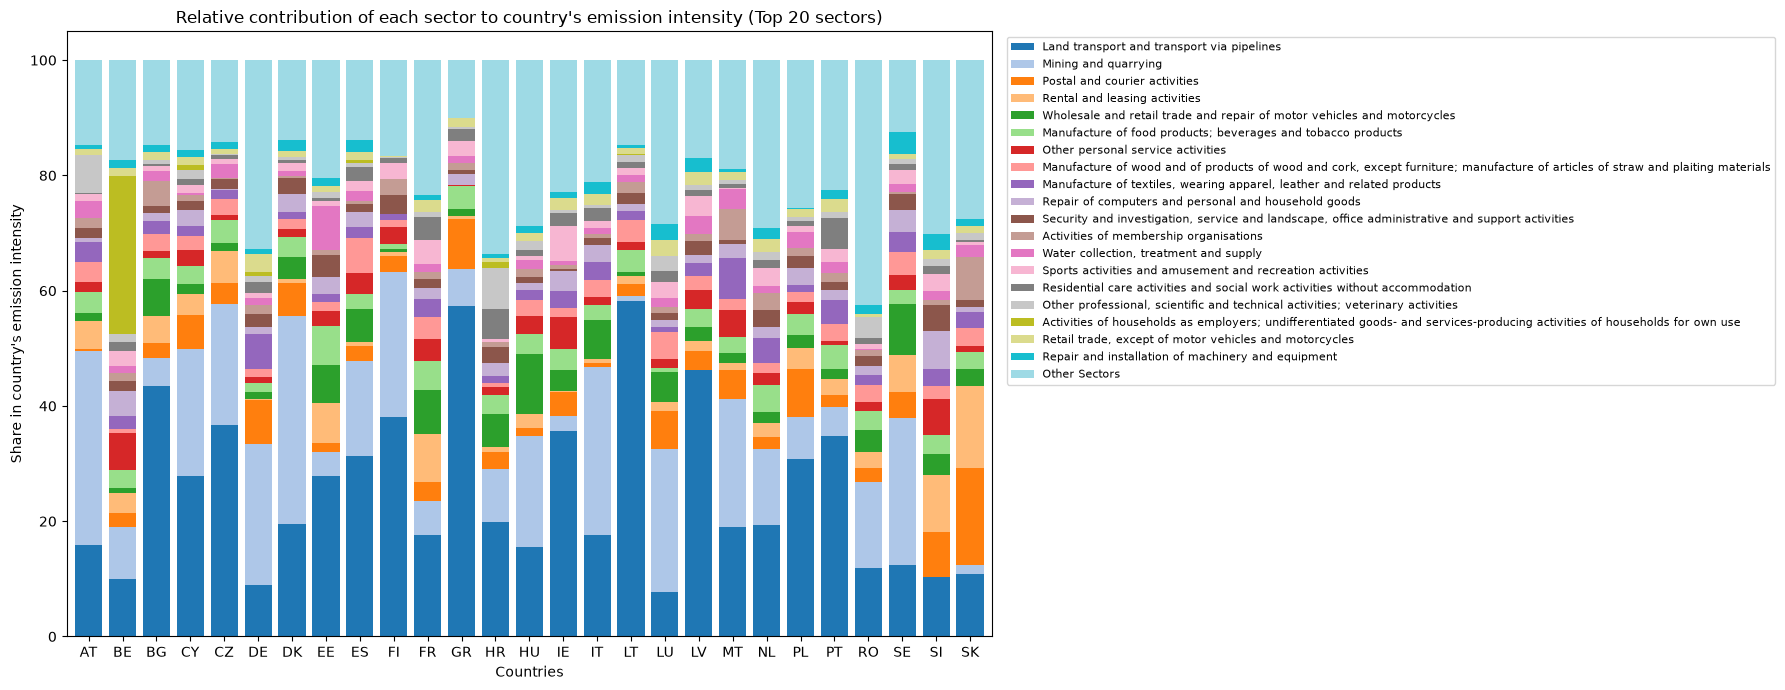

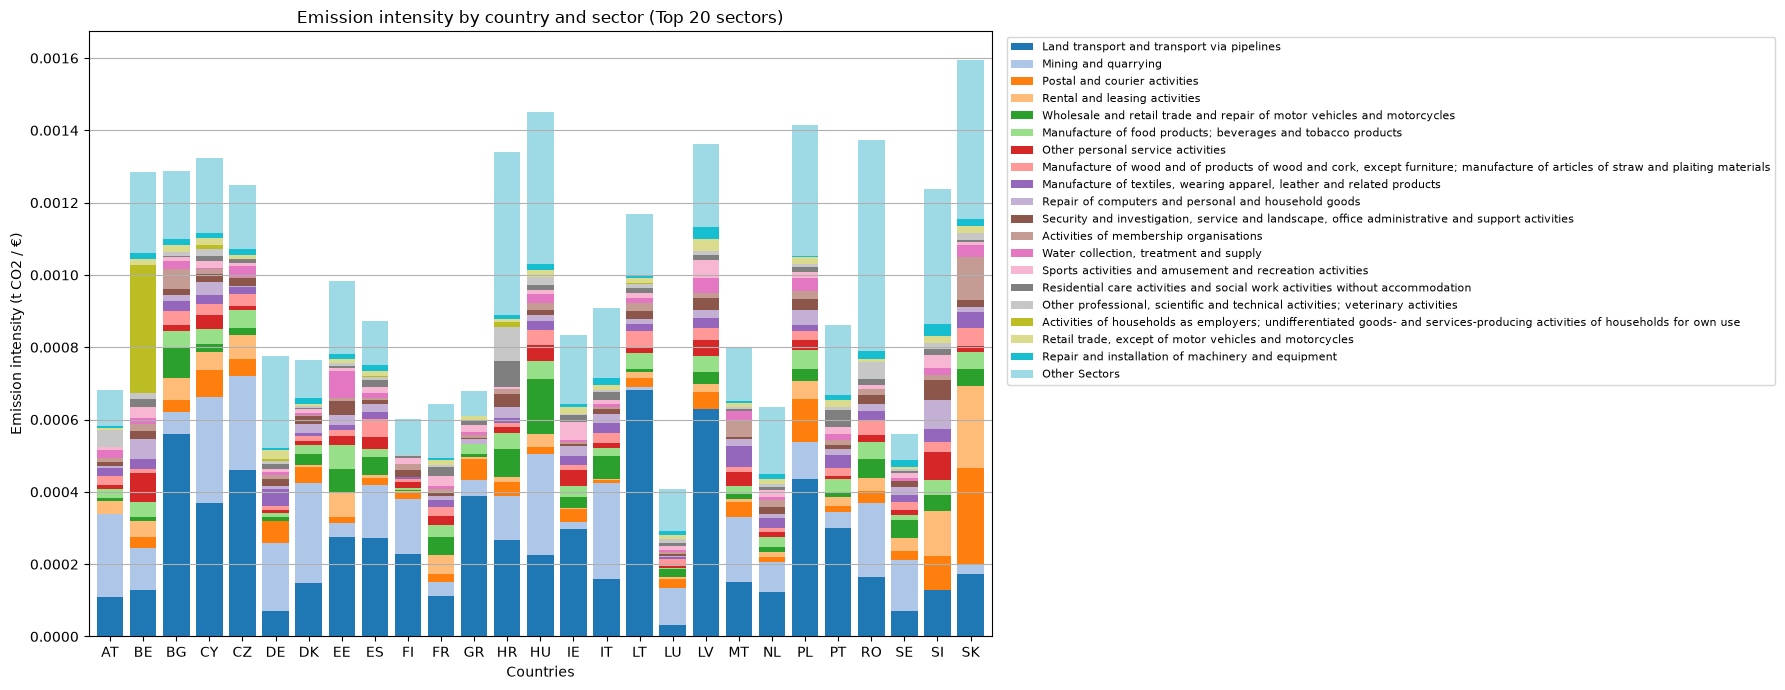

In [118]:
df = q.develop().to_pandas()

top20 = df.sum().nlargest(19).index
pct = df.div(df.sum(axis=1), axis=0) * 100
plot_df = pct[top20].copy()
plot_df["Other Sectors"] = pct.drop(columns=top20).sum(axis=1)

abs_df = df[top20].copy()
abs_df["Other Sectors"] = df.drop(columns=top20).sum(axis=1)

cmap = plt.get_cmap("tab20")
colors = [cmap(i) for i in range(20)]


fig1, ax1 = plt.subplots(figsize=(18, 7))
plot_df.plot(kind="bar", stacked=True, ax=ax1, color=colors, width=0.8, legend=False)
ax1.set_title("Relative contribution of each sector to country's emission intensity (Top 20 sectors)")
ax1.set_ylabel("Share in country's emission intensity")
ax1.set_xlabel("Countries")
ax1.set_xticklabels(plot_df.index, rotation=0)
ax1.legend(plot_df.columns, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

fig1.tight_layout()
fig1.savefig(os.path.join(figure_path, "bar_relative_contribution_to_emission_intensity_by_country_and_sector.png"),
             bbox_inches='tight', dpi=300)
plt.show()

fig2, ax2 = plt.subplots(figsize=(18, 7))
abs_df.plot(kind="bar", stacked=True, ax=ax2, color=colors, width=0.8, legend=False)
ax2.set_title("Emission intensity by country and sector (Top 20 sectors)")
ax2.set_ylabel("Emission intensity (t CO2 / €)")
ax2.set_xlabel("Countries")
ax2.set_xticklabels(abs_df.index, rotation=0)
ax2.legend(abs_df.columns, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
# add a horizontal grid
ax2.yaxis.grid(True, which='major')

fig2.tight_layout()
fig2.savefig(os.path.join(figure_path, "bar_emission_intensity_by_country_and_sector.png"),
             bbox_inches='tight', dpi=300)
plt.show()

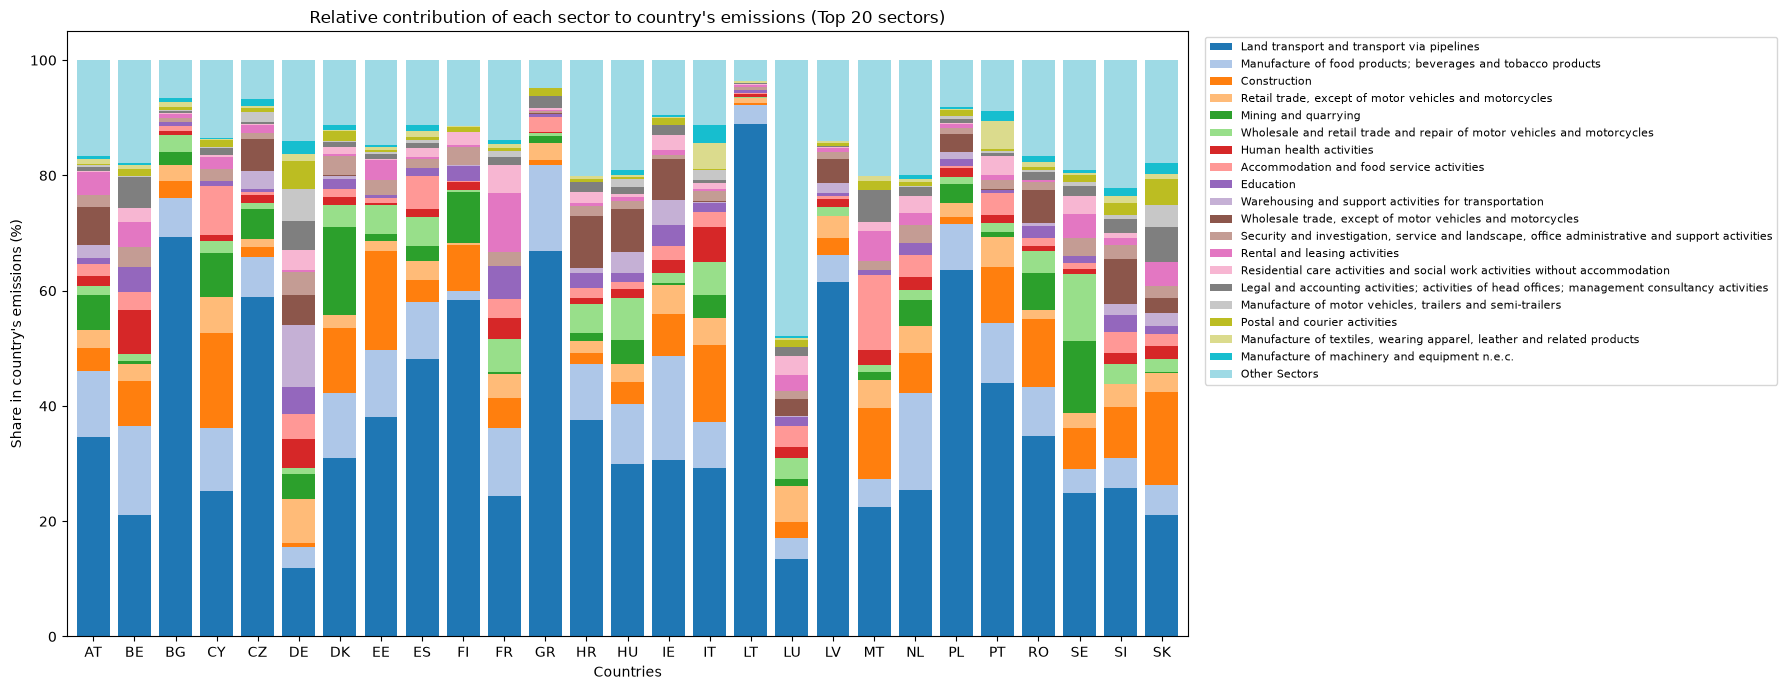

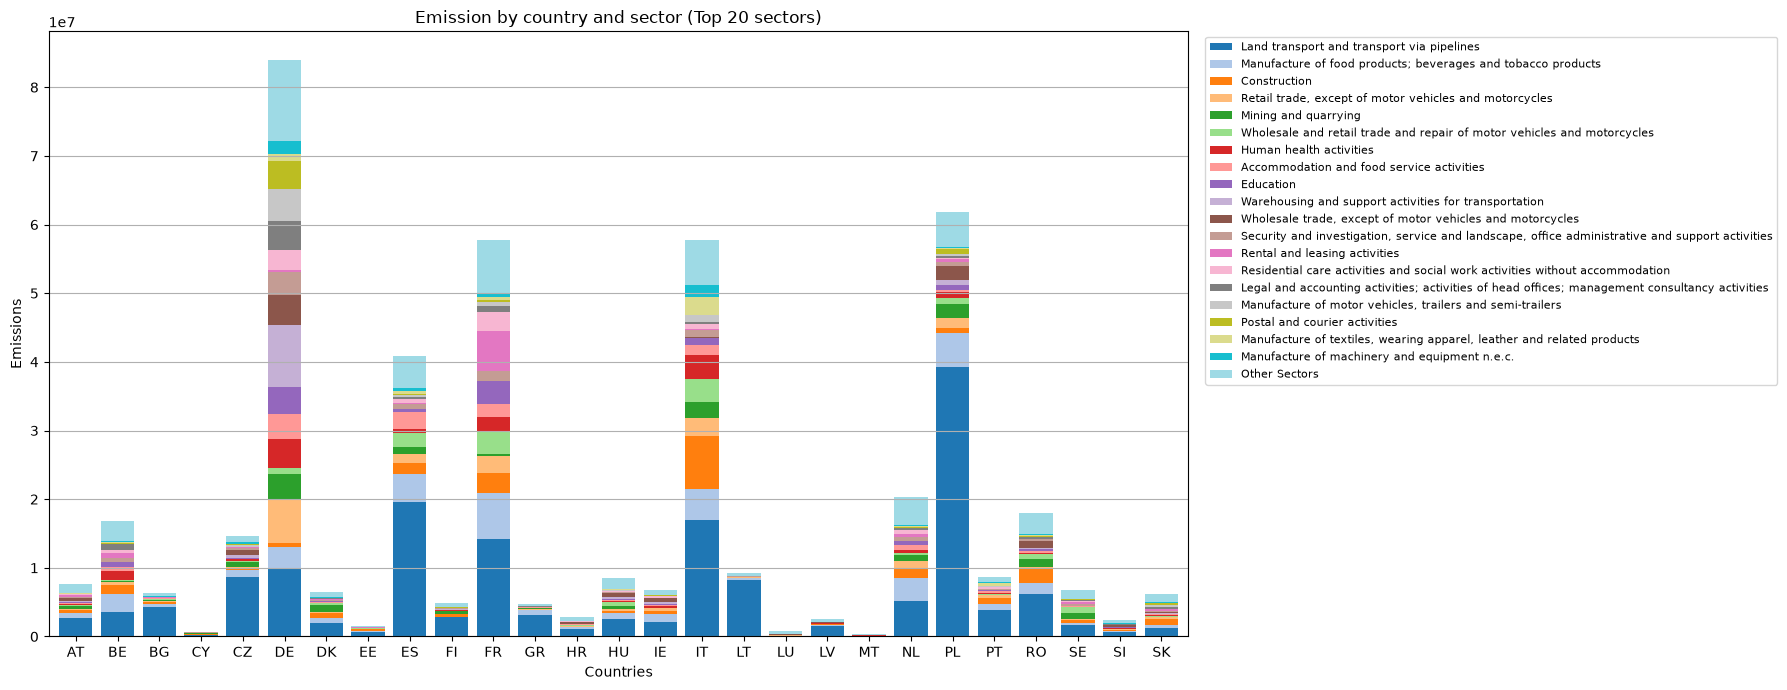

In [119]:
df = Q.develop().to_pandas()

top20 = df.sum().nlargest(19).index
pct = df.div(df.sum(axis=1), axis=0) * 100
plot_df = pct[top20].copy()
plot_df["Other Sectors"] = pct.drop(columns=top20).sum(axis=1)

abs_df = df[top20].copy()
abs_df["Other Sectors"] = df.drop(columns=top20).sum(axis=1)

cmap = plt.get_cmap("tab20")
colors = [cmap(i) for i in range(20)]


fig1, ax1 = plt.subplots(figsize=(18, 7))
plot_df.plot(kind="bar", stacked=True, ax=ax1, color=colors, width=0.8, legend=False)
ax1.set_title("Relative contribution of each sector to country's emissions (Top 20 sectors)")
ax1.set_ylabel("Share in country's emissions (%)")
ax1.set_xlabel("Countries")
ax1.set_xticklabels(plot_df.index, rotation=0)
ax1.legend(plot_df.columns, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

fig1.tight_layout()
fig1.savefig(os.path.join(figure_path, "bar_relative_contribution_to_emissions_by_country_and_sector.png"),
             bbox_inches='tight', dpi=300)
#plt.show()

fig2, ax2 = plt.subplots(figsize=(18, 7))
abs_df.plot(kind="bar", stacked=True, ax=ax2, color=colors, width=0.8, legend=False)
ax2.set_title("Emission by country and sector (Top 20 sectors)")
ax2.set_ylabel("Emissions")
ax2.set_xlabel("Countries")
ax2.set_xticklabels(abs_df.index, rotation=0)
ax2.legend(abs_df.columns, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
# add a horizontal grid
ax2.yaxis.grid(True, which='major')

fig2.tight_layout()
fig2.savefig(os.path.join(figure_path, "bar_emissions_by_country_and_sector.png"),
             bbox_inches='tight', dpi=300)
#plt.show()

## Carbon model

To model the impact of the ETS on consumer prices, we first model the impact on sectoral prices and then use bridging matrices and consumption baskets to transform sectoral inflation to consumer price inflation. 

Sectoral inflation is computed with a cost push model. Consider the basic price model: 

$$ x' = i' Z + v'$$

with $x$ as the output column vector, $Z$ the intermediate demand matrix, $i$ the summation operator, i.e. a column vector of ones, and $v$ the value added expenditures vector. In words, this equation states that total outlays have to be equal to total output. 

Substituting $Z = A \hat X $ leads to: 

$$ x' = i' A \hat X + v'$$

To express everything per unit of output, we postmultiply by $\hat x ^ {-1}$: 

$$ i' = i' A + v_c'$$

We follow the notation in Miller and Blair and define $v_c' = v' \hat x ^{-1}$ as the value added costs per unit of output. As prices equal production costs (which include profits, wages, imports, taxes etc), each price is equal to 1 and we can write: 

$$ p' = p' A + v_c'$$

Re-arranging and applying the Leontief inverse yields:

$$ p' = v_c' (I - A)^{-1} = v_c'L$$

If we write the value added vector as a diagonal matrix, then the price vector becomes a price matrix. This allows us to later distinguish between the origin and the destination of a price shock and thus to capture imported and exported inflationary pressures. 

$$ P = \hat v_c (I - A)^{-1} = \hat v_c L$$


If we apply a carbon price, this will mechanically increase the value added component $V_c'L$ and vla the Leontief inverse increase the overall price level in the economy. Note that 

$$\Delta P  = \Delta \hat v_c L$$

and $ \Delta \hat v_c = \Delta (\hat \tau \hat q) $ with $\tau$ the column vector of carbon prices and $ \hat q = \hat Q \hat X ^{-1} $ the vector of emission intensities per unit of output. 

So we arrive at the final model for sectoral carbon prices with:

$$\Delta P  = \Delta \hat \tau \hat q L$$

The structure of the $\Delta P$ matrix can be read similar to that of a multi-regional intermediate demand matrix:

$$
\Delta P = \begin{bmatrix}
\Delta p_{1,1 \rightarrow 1,1} & \Delta p_{1,1 \rightarrow 1,2} & \cdots & \Delta p_{1,1 \rightarrow 1,S} & \Delta p_{1,1 \rightarrow 2,1} & \cdots & \Delta p_{1,1 \rightarrow C,S} \\
\Delta p_{1,2 \rightarrow 1,1} & \Delta p_{1,2 \rightarrow 1,2} & \cdots & \Delta p_{1,2 \rightarrow 1,S} & \Delta p_{1,2 \rightarrow 2,1} & \cdots & \Delta p_{1,2 \rightarrow C,S} \\
\vdots & \vdots & \ddots & \vdots & \vdots & \ddots & \vdots \\
\Delta p_{1,S \rightarrow 1,1} & \Delta p_{1,S \rightarrow 1,2} & \cdots & \Delta p_{1,S \rightarrow 1,S} & \Delta p_{1,S \rightarrow 2,1} & \cdots & \Delta p_{1,S \rightarrow C,S} \\
\Delta p_{2,1 \rightarrow 1,1} & \Delta p_{2,1 \rightarrow 1,2} & \cdots & \Delta p_{2,1 \rightarrow 1,S} & \Delta p_{2,1 \rightarrow 2,1} & \cdots & \Delta p_{2,1 \rightarrow C,S} \\
\vdots & \vdots & \ddots & \vdots & \vdots & \ddots & \vdots \\
\Delta p_{C,S \rightarrow 1,1} & \Delta p_{C,S \rightarrow 1,2} & \cdots & \Delta p_{C,S \rightarrow 1,S} & \Delta p_{C,S \rightarrow 2,1} & \cdots & \Delta p_{C,S \rightarrow C,S} \\
\end{bmatrix}
$$

where each element $\Delta p_{c,s \rightarrow c',s'}$ denotes the destination of a price increase in an originating country-sector combination $(c,s)$ on the price of another country-sector combination $(c',s')$ for sectors $s \in (1, ..., S)$ and countries $c \in (1, ... , C)$ with S and C being the respective number of sectors and countries in the model. Thus, the rows show the downstream origin of a price shock while the columns show its upstream destination. For example, the first row of the matrix corresponds to a price increase in the first sector of the first country, while all the elements of that first row depict the effect on every other country-sector combination. The diagonal elements are the destination of a carbon price increase on the price of the country-sector combination itself.

We can separately compute this model with carbon price changes for the ETS1 and the ETS2. Whenever a sector $s$ in a country $c$ is not covered by a carbon taxing scheme, it has a tax rate $\tau_{s,c} = 0$

In [120]:
# construct tau vector (one vertical axis with the two dimensions countries and sectors)
dtau = Part(labels = {"0": {"countries" : countries, "sectors" : sectors}}, name = "delta_tau")
price_changes = pd.read_excel("../data/carbon prices/carbon price changes.xlsx", sheet_name="carbon_price_changes")
price_changes = price_changes.set_index("country")[price_scenario].to_dict()

for country in countries: 
    dtau[country] = price_changes[country]

# diagonalize delta tau
dtau_diag = dtau.diag()
q_diag = q.diag()

P = dtau_diag.mul(q_diag).mul(L)

# convert to percentage change
P = 100*P

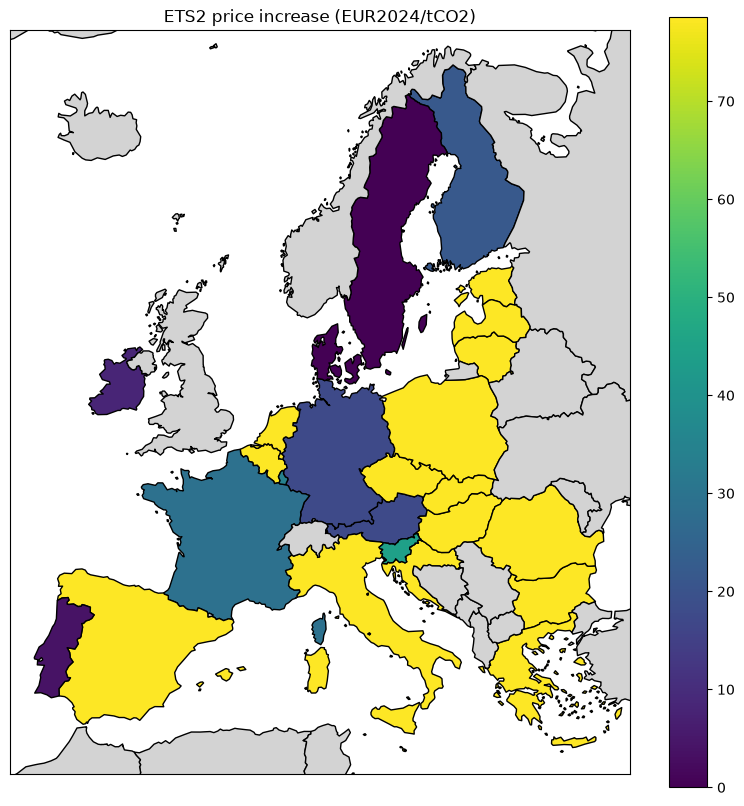

In [121]:
#Overview map of ETS2 price changes by country

price_changes_df = pd.DataFrame(price_changes.items(), columns=["Country", "price_change"])
price_changes_df = price_changes_df[price_changes_df["Country"].isin(countries)] # filter to only include EU countries

gdf_pc = gpd.read_file("../data/geodata/CNTR_RG_20M_2024_3035.gpkg")
# rename EL to GR in the GeoDataFrame
gdf_pc["CNTR_ID"] = gdf_pc["CNTR_ID"].replace({"EL": "GR"})
gdf_pc = gdf_pc.merge(price_changes_df, left_on="CNTR_ID", right_on="Country", how="left")

ax = gdf_pc.plot(column='price_change', 
              cmap='viridis',       
              legend=True,           
              figsize=(10, 10),
              missing_kwds={'color': 'lightgrey'},
              edgecolor='black')

# Set axis limits to only display the EU region
ax.set_xlim(2500000, 6000000)
ax.set_ylim(1300000, 5500000)
plt.title("ETS2 price increase (EUR2024/tCO2)")
ax.set_xticks([])
ax.set_yticks([])
plt.savefig(os.path.join(figure_path, "map_price_increase.png"), bbox_inches='tight', dpi=300)
plt.show()

## Transform industry inflation impact to hicp impact
### From NACE2 to CPA to COICOP to HICP
To get from the sectoral inflation to the CPI impact, we go throught he following steps: 
1. We now transform sectoral inflation impacts on the industry level to the product level using our market share matrix. 
2. Then, we transform this to the COICOP level using [this bridging matrix](https://www.sciencedirect.com/science/article/pii/S2352340920302894#ecom0002). We will assume that intertemporal stability of the briding coefficients for the year 2015 holds, following [Kronenberg 2011](https://io4.shaio.es/paper/pap15.pdf). 
3. Then, we will compute inflation impact using the hicp inflation weights from eurostat. 

We normalize the supply table and compute the market share matrix C by dividing each column of S by the respective column sum.

In [122]:
C = S / x_s
C.data = np.nan_to_num(C.data, nan=0.0) 

/home/florian/Wissenschaft/eu-ets-inflation-impact/mrio_toolbox/mrio_toolbox/_parts/_Part.py:1724: RuntimeWarning: invalid value encountered in divide
  return self.alias(data=self.data/a,


### Download and harmonize hicp data

In [123]:
hicp = eurostat.get_data_df("prc_hicp_inw")
hicp = hicp.melt(id_vars=["freq", "coicop", "geo\\TIME_PERIOD"],var_name="year", value_name="value")
hicp = hicp.rename(columns={"geo\\TIME_PERIOD": "geo"})
hicp["year"] = hicp["year"].astype(int)
hicp = hicp[hicp["year"] == year]

# Aggregate residual categories CP122 to CP127 to harmonize Coicop labels between the datasets for hicp weights and the bridge matrix. 
hicp["coicop"] = hicp["coicop"].replace({
    "CP122": "CP122_127",
    "CP123": "CP122_127",
    "CP124": "CP122_127",
    "CP125": "CP122_127",
    "CP126": "CP122_127",
    "CP127": "CP122_127"
})

hicp["geo"] = hicp["geo"].replace({"EL": "GR"}) # replace "EL" with "GR" for Greece
hicp = hicp[hicp["geo"].isin(countries)]  # Filter for countries in the MRIO model
hicp = hicp.groupby(["geo", "coicop", "year"], as_index=False)["value"].sum()
bridging_matrix_df = pd.read_excel("../data/CPA to COICOP mapping/bridging_matrix_2016.xlsx", sheet_name=country, header=0, index_col=0)
coicop_labs = bridging_matrix_df.columns.tolist()
coicop_labs.remove("CP042") #imputed rents are not in hicp weights


In [124]:
# VAT rates sourced from https://europa.eu/youreurope/business/finance-and-tax/vat/vat-rules-rates/index_en.htm 
# As a simplification, we use standard rates for each country, even though some countries have reduced rates for certain goods and services.

vat_rates = {
    "AT": 0.20,
    "BE": 0.21,
    "BG": 0.20,
    "CY": 0.19,
    "CZ": 0.21,
    "DE": 0.19,
    "DK": 0.25,
    "EE": 0.24,
    "ES": 0.21,
    "FI": 0.255,
    "FR": 0.20,
    "GR": 0.24,
    "HR": 0.25,
    "HU": 0.27,
    "IE": 0.23,
    "IT": 0.22,
    "LT": 0.21,
    "LU": 0.17,
    "LV": 0.21,
    "MT": 0.18,
    "NL": 0.21,
    "PL": 0.23,
    "PT": 0.23,
    "RO": 0.21,
    "SE": 0.25,
    "SI": 0.22,
    "SK": 0.23
}


### Compute inflation impact

A note on the naming conventions: 
- dP_csd is a country/sector vector that holds the sector level inflation caused by that sector in all other sectors in the EU (related to that sector's forward linkage)
  - dP_csd_d = dP_rec_d is the direct price increase of that sector on itself
  - dP_csd_i is the indirect price increase which that sector causes in other sectors
- dP_rec is a country/sector vector that holds the sector level inflation received by that sector, either through its own price increase or the price increase in other sectors
  - dP_rec_d = dP_csd_d is the direct price increase of that sector itself
  - dP_rec_i is the indirect price increase which is caused by other sectors in that sector

- cpa relates to the CPA classification, ccp relates to the coicop classification. 

In [125]:
# direct and indirect received and caused inflation in NACE classification
dP_csd = P.sum(axis=1).alias(data = P.sum(axis = 1))
dP_csd_d = dP_csd.alias(data = P.data.diagonal()) 
dP_csd_i = dP_csd.alias(data = dP_csd.data - dP_csd_d.data) 
dP_rec = P.sum(axis=0).alias(data = P.sum(axis = 0))
dP_rec_d = dP_csd_d
dP_rec_i = dP_csd.alias(data = dP_rec.data - dP_rec_d.data)

# convert to cpa classification
dP_rec_cpa = C.mul(dP_rec)
dP_rec_d_cpa = C.mul(dP_rec_d)
dP_rec_i_cpa = C.mul(dP_rec_i)

dP_rec_ccp = Part(labels = [[{"countries":countries, "ccp":coicop_labs}],])
dP_rec_d_ccp = Part(labels = [[{"countries":countries, "ccp":coicop_labs}],])
dP_rec_i_ccp = Part(labels = [[{"countries":countries, "ccp":coicop_labs}],])

all_sectors = sectors + ["Household heating emissions", "Household transport emissions"]
sectoral_rec = Part(labels = [[{"countries":countries}],[{"sectors":all_sectors}]])
sectoral_rec_ccp = Part(labels = [[{"countries":countries, "ccp":coicop_labs}],])

# create new dataframe to store computed hicp inflation impacts 
df = pd.DataFrame(index = countries)
df["rec"] = dP_rec.sum(on="sectors").data
df["rec_d"] = dP_rec_d.sum(on="sectors").data
df["rec_i"] = dP_rec_i.sum(on="sectors").data

In [126]:
for country in countries:

    # prepare bridging matrix
    bridging_matrix_df = pd.read_excel("../data/CPA to COICOP mapping/bridging_matrix_2016.xlsx", sheet_name=country, header=0, index_col=0)
    bridging_matrix_df = bridging_matrix_df.drop('CP042',axis=1) # imputed rents are not in hicp data
    
    # append row for CPA_U so matrix multiplication works (CPA_U is always 0)
    series = np.zeros(len(bridging_matrix_df.columns), dtype=float)
    bridging_matrix_df.loc["CPA_U"] = series 
    
    # make new part object for the bridging matrix of each country
    data = bridging_matrix_df.to_numpy(dtype=float)
    cpa_labs = bridging_matrix_df.index.tolist()
    coicop_labs = bridging_matrix_df.columns.tolist()
    bridging_matrix = Part(data = data, name = "bridging_matrix", labels = [cpa_labs, coicop_labs])
    bridging_matrix = bridging_matrix.transpose()  # coicop labels on vertical axis
    bridging_matrix /= bridging_matrix.sum(axis=0)  # normalize
    bridging_matrix.data = np.nan_to_num(bridging_matrix.data, nan=0.0)
    
    # load hicp weights for the country
    hicp_weights = hicp[hicp["coicop"].isin(coicop_labs)]
    hicp_weights = hicp_weights[hicp_weights["geo"] == country]["value"].to_numpy()
    hicp_weights = hicp_weights / 1000 # normalize hicp weights to sum to 1
    
    # national-only received inflation in cpa
    dP_rec_nat = P[country, country].sum(axis=0).alias(data = P[country, country].sum(axis = 0))
    dP_rec_nat_cpa = C[country, country].mul(dP_rec_nat) 
    
    # cpa -> coicop classifcation
    dP_rec_ccp[country, "all"] = bridging_matrix.mul(dP_rec_cpa[country, "all"])
    dP_rec_d_ccp[country, "all"] = bridging_matrix.mul(dP_rec_d_cpa[country, "all"])
    dP_rec_i_ccp[country, "all"] = bridging_matrix.mul(dP_rec_i_cpa[country, "all"])
    dP_rec_nat_ccp = bridging_matrix.mul(dP_rec_nat_cpa[country, "all"])

    # compute direct hicp increase by heating and transport emissions
    extra_costs_heating = (qy["1.A.4.b.gaseous", [country, "Heating/cooling activities by households"]].data.item() \
        + qy["1.A.4.b.liquid", [country, "Heating/cooling activities by households"]].data.item() \
        + qy["1.A.4.b.solid", [country, "Heating/cooling activities by households"]].data.item() \
        + qy["1.A.4.b.other", [country, "Heating/cooling activities by households"]].data.item()
        ) * price_changes[country] 
    extra_costs_transport = qy["1.A.3.b.i", [country, "Transport activities by households"]].data.item() * price_changes[country] 
    
    df.loc[country, "hicp_heating"] = (1 + vat_rates[country]) *(extra_costs_heating / Y.sum(axis = 0)[country, "Final consumption expenditure of households"].data.item()) * 100 # convert to percentage change
    df.loc[country, "hicp_personal_transport"] = (1 + vat_rates[country])*(extra_costs_transport / Y.sum(axis = 0)[country, "Final consumption expenditure of households"].data.item()) * 100 # convert to percentage change
    df.loc[country, "hicp_energy"] = df.loc[country, "hicp_heating"] + df.loc[country, "hicp_personal_transport"]
    
    # coicop -> hicp 
    df.loc[country, "hicp_product"] = hicp_weights @ dP_rec_ccp[country, "all"].data * (1 + vat_rates[country])
    df.loc[country, "hicp_product_d"] = hicp_weights @ dP_rec_d_ccp[country, "all"].data * (1 + vat_rates[country])
    df.loc[country, "hicp_product_i"] = hicp_weights @ dP_rec_i_ccp[country, "all"].data  * (1 + vat_rates[country])
    df.loc[country, "hicp_product_nat"] = hicp_weights @ dP_rec_nat_ccp.data  * (1 + vat_rates[country])
    
    df.loc[country, "hicp_total"] = df.loc[country, "hicp_product"] + df.loc[country, "hicp_energy"]
    df.loc[country, "hicp_national"] = df.loc[country, "hicp_product_nat"] + df.loc[country, "hicp_energy"]
    
    # sector-specific contribution to product level hicp exposure
    for sector in sectors:
        # shock each sector individually to see its exposure to HICP inflation from all other sectors
        rec_NACE = dP_rec.alias(data = np.zeros(dP_rec.shape))
        rec_NACE[country,sector] = dP_rec[country, sector]
        
        # nace -> cpa
        sectoral_rec_cpa = C.mul(rec_NACE)
        # cpa -> coicop
        sectoral_rec_ccp[country, "all"] = bridging_matrix.mul(sectoral_rec_cpa[country, "all"]) 
        # coicop -> hicp
        sectoral_rec[country, sector] = hicp_weights @ sectoral_rec_ccp[country, "all"].data * (1 + vat_rates[country])
    
    sectoral_rec[country, "Household heating emissions"] = df.loc[country, "hicp_heating"] 
    sectoral_rec[country, "Household transport emissions"] = df.loc[country, "hicp_personal_transport"]
    
    # compute average Q for each country
    df.loc[country, "avg_Q"] = Q.sum(on="sectors")[country].data.item() / X.sum(on = "sectors")[country].data.item()
    
    # add final demand
    df.loc[country, "final_demand"] = Y.sum(axis = 0)[country, "Final consumption expenditure of households"].data.item()
# imported inflation from other european countries    
df["hicp_from_foreign"] = df["hicp_total"] - df["hicp_national"]

/home/florian/Wissenschaft/eu-ets-inflation-impact/mrio_toolbox/mrio_toolbox/_parts/_Part.py:1724: RuntimeWarning: invalid value encountered in divide
  return self.alias(data=self.data/a,
/home/florian/Wissenschaft/eu-ets-inflation-impact/mrio_toolbox/mrio_toolbox/_parts/_Part.py:1724: RuntimeWarning: invalid value encountered in divide
  return self.alias(data=self.data/a,
/home/florian/Wissenschaft/eu-ets-inflation-impact/mrio_toolbox/mrio_toolbox/_parts/_Part.py:1724: RuntimeWarning: invalid value encountered in divide
  return self.alias(data=self.data/a,
/home/florian/Wissenschaft/eu-ets-inflation-impact/mrio_toolbox/mrio_toolbox/_parts/_Part.py:1724: RuntimeWarning: invalid value encountered in divide
  return self.alias(data=self.data/a,
/home/florian/Wissenschaft/eu-ets-inflation-impact/mrio_toolbox/mrio_toolbox/_parts/_Part.py:1724: RuntimeWarning: invalid value encountered in divide
  return self.alias(data=self.data/a,
/home/florian/Wissenschaft/eu-ets-inflation-impact/mrio

### Adding GDP and population variables to main dataframe

In [127]:
if not os.path.exists("../data/sociodemographic_data/gdp_data.csv") or not os.path.exists("../data/sociodemographic_data/population_data.csv"):
    print("Sociodemographic data files not found. Downloading from Eurostat...")
    gdp_df = eurostat.get_data_df("nama_10_gdp") 
    pop_df = eurostat.get_data_df("demo_pjangroup")
    # save sociodemographic data to csv file
    path = "../data/sociodemographic_data"
    os.makedirs(path, exist_ok=True)  # Create directory if it doesn't exist
    gdp_df.to_csv(os.path.join(path, "gdp_data.csv"), index=False)
    pop_df.to_csv(os.path.join(path, "population_data.csv"), index=False)
else:
    # load sociodemographic data from csv files
    gdp_df = pd.read_csv("../data/sociodemographic_data/gdp_data.csv")
    pop_df = pd.read_csv("../data/sociodemographic_data/population_data.csv")

In [128]:
# rename EL to GR in both dataframes
gdp_df["geo\\TIME_PERIOD"] = gdp_df["geo\\TIME_PERIOD"].replace({"EL": "GR"})
pop_df["geo\\TIME_PERIOD"] = pop_df["geo\\TIME_PERIOD"].replace({"EL": "GR"})

gdp_df = gdp_df[
    (gdp_df["geo\\TIME_PERIOD"].isin(countries)) & # filter for the year 2022
    (gdp_df["na_item"] == "B1GQ") & # GDP (gross domestic product at market prices)
    (gdp_df["unit"] == "CP_MEUR") # current prices, million euro
    ][["geo\\TIME_PERIOD", "2022"]]

pop_df = pop_df[
    (pop_df["geo\\TIME_PERIOD"].isin(countries)) &
    (pop_df["age"] == "TOTAL") &
    (pop_df["sex"] == "T")
][["geo\\TIME_PERIOD", "2022"]].reset_index(drop=True)

df["GDP"] = gdp_df.set_index("geo\\TIME_PERIOD")["2022"].astype(float) 
df["POP"] = pop_df.set_index("geo\\TIME_PERIOD")["2022"].astype(float)
df["GDP_per_capita"] = df["GDP"] / df["POP"]

for country in countries:
    # average relative and absolute emission intensity of the country in tCO2 per million € output
    df.loc[country, "Q"] = Q[country].sum(axis=0).data * 1e6
    df.loc[country, "q"] = Q[country] / df.loc[country, "GDP"] * 1e6  # Emission intensity in tCO2 per million € output

## Imported and exported inflation

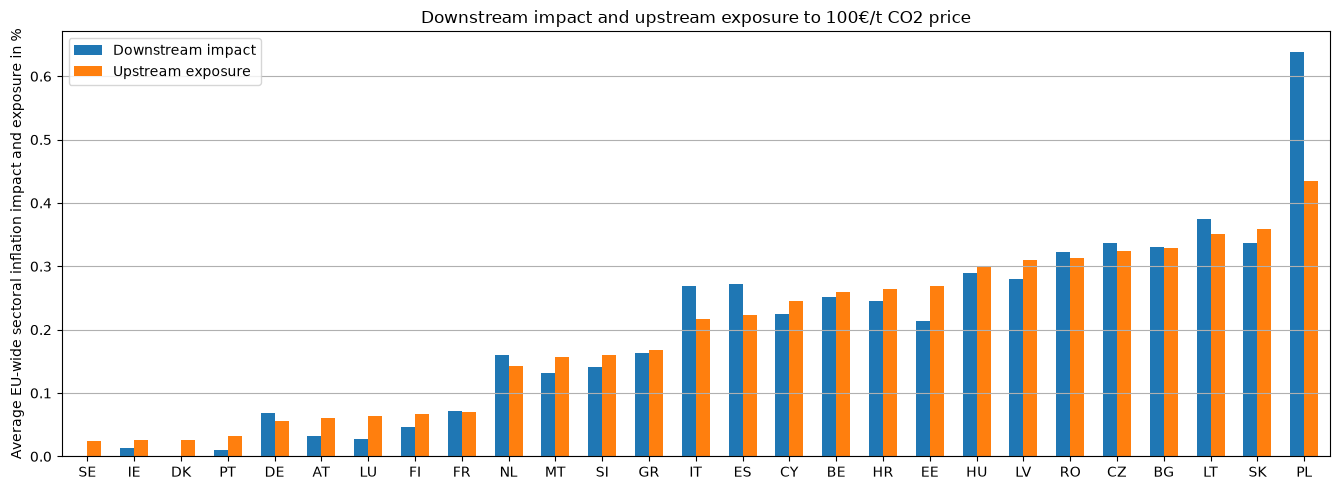

In [129]:

df["csd_aggr"] = dP_csd.sum(on="sectors").data /len(sectors)
df["rec_aggr"] = dP_rec.sum(on="sectors").data /len(sectors)

df_sorted = df.sort_values(by="rec_aggr")

ax = df_sorted[["csd_aggr", "rec_aggr"]].plot.bar(
    figsize=(0.5 * len(countries), 5),
    rot=0,
    width=0.6, 
    title="Downstream impact and upstream exposure to 100€/t CO2 price",
)
ax.grid(axis="y") 
ax.set_ylabel("Average EU-wide sectoral inflation impact and exposure in %")
ax.legend(["Downstream impact", "Upstream exposure"])#

plt.tight_layout()
plt.savefig(os.path.join(figure_path, "bar_average_regional_impact_exposure.png"), bbox_inches='tight', dpi=300)
plt.show()

Comment for Jonas: Not entirely sure, if we need this graph, maybe don't put it in the paper / presentation

## Heatmaps

### Normalized deltaP by country and sector

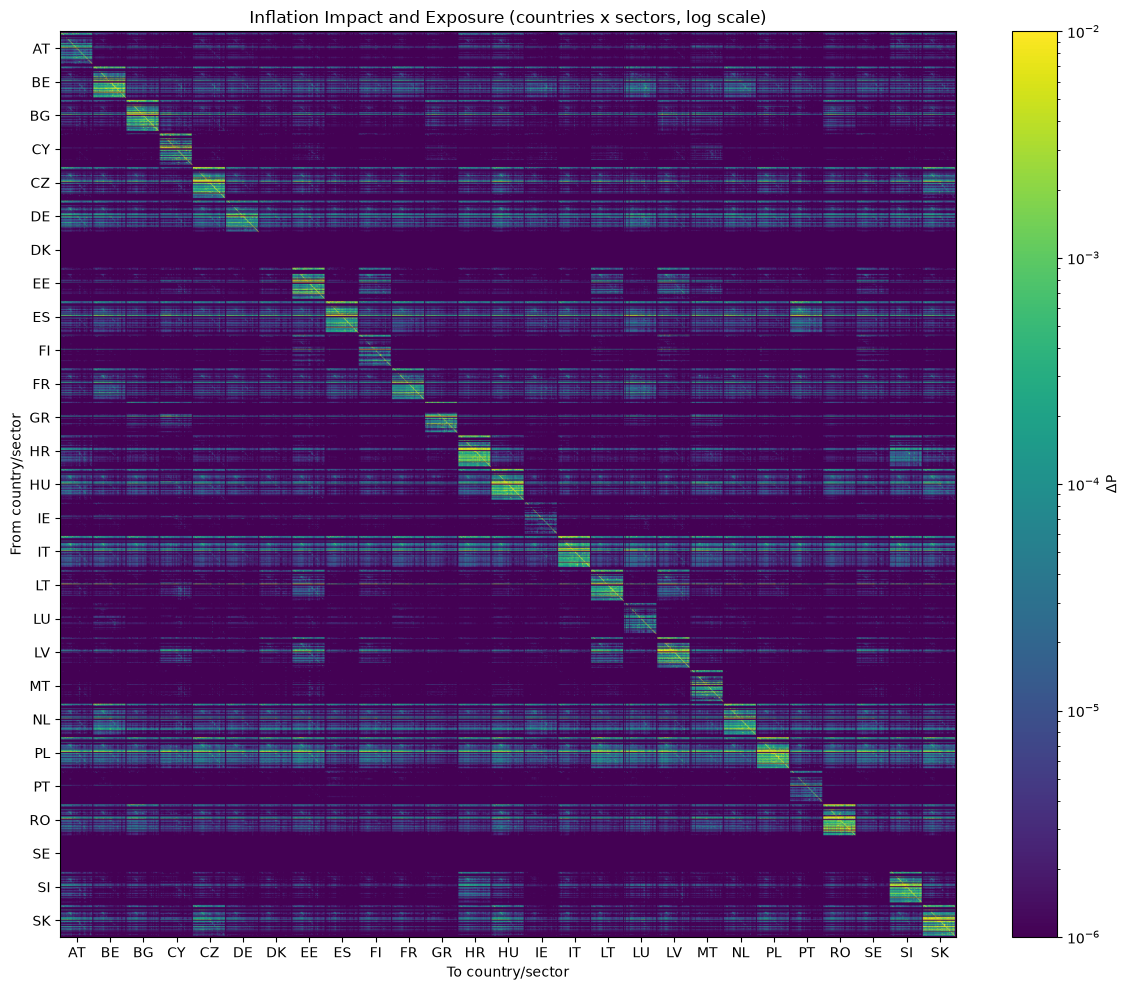

In [130]:
values = abs(P.data)
values[values == 0] = 1e-6  # Avoid log(0)
values[values < 1e-6] = 1e-6
values[values > 0.01] = 0.01 

n_rows, n_cols = values.shape

# Assuming 64 sectors per country
sectors_per_country = 64
num_countries_x = n_cols // sectors_per_country
num_countries_y = n_rows // sectors_per_country

# Centered tick positions
x_ticks = np.arange(sectors_per_country // 2, n_cols, sectors_per_country)
y_ticks = np.arange(sectors_per_country // 2, n_rows, sectors_per_country)

# Labels (truncate if necessary)
x_labels = countries[:len(x_ticks)]
y_labels = countries[:len(y_ticks)]

plt.figure(figsize=(12, 10))
plt.imshow(values, cmap='viridis', aspect='auto', norm=LogNorm())

plt.colorbar(label='ΔP')
plt.title("Inflation Impact and Exposure (countries x sectors, log scale)")
plt.xlabel("To country/sector")
plt.ylabel("From country/sector")

# Centered country labels
plt.xticks(ticks=x_ticks, labels=x_labels)
plt.yticks(ticks=y_ticks, labels=y_labels)

plt.tight_layout()
plt.savefig(os.path.join(figure_path, "heatmap_countries_sectors.png"), bbox_inches='tight', dpi=300)
plt.show()


## Actual HICP inflation
### Direct and indirect effects

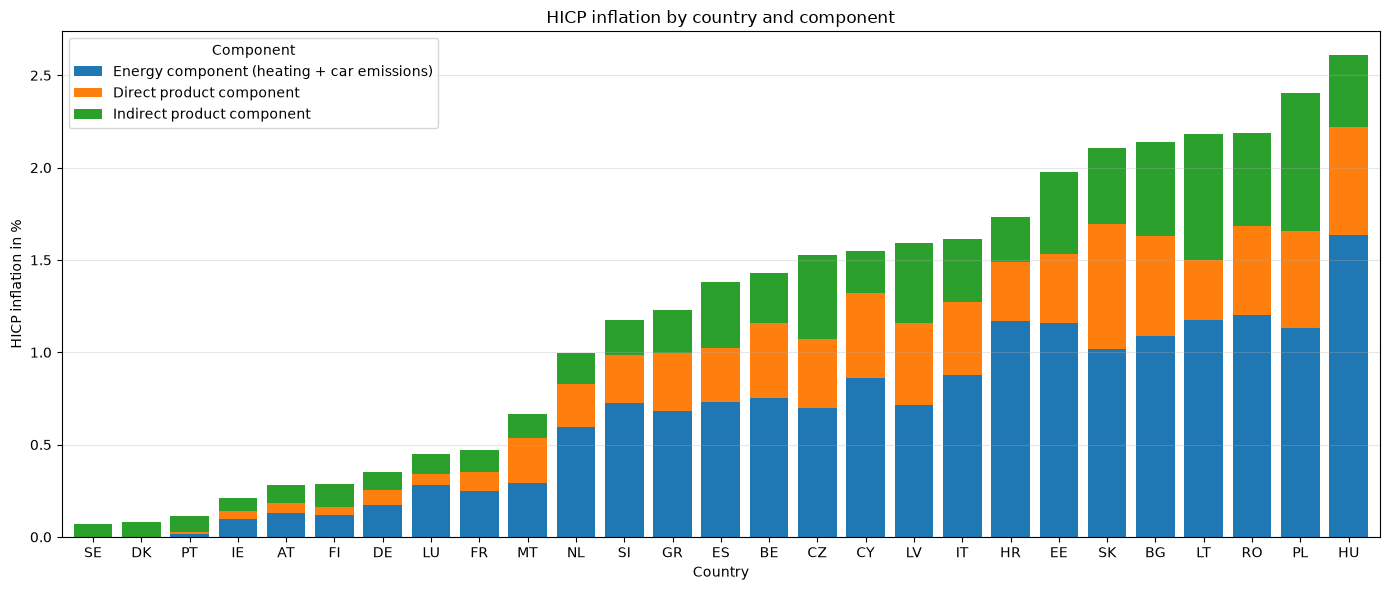

In [131]:
plot_df = df.sort_values(by = "hicp_total")[["hicp_energy","hicp_product_d","hicp_product_i"]].copy()

ax = plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6),
    width=0.8
)

ax.set_xlabel("Country")
ax.set_ylabel("HICP inflation in %")
ax.set_title("HICP inflation by country and component")
ax.legend(
    ["Energy component (heating + car emissions)", "Direct product component", "Indirect product component"],
    title="Component"
)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(figure_path, "bar_hicp_inflation_by_country_and_component.png"), bbox_inches='tight', dpi=300)
plt.show()

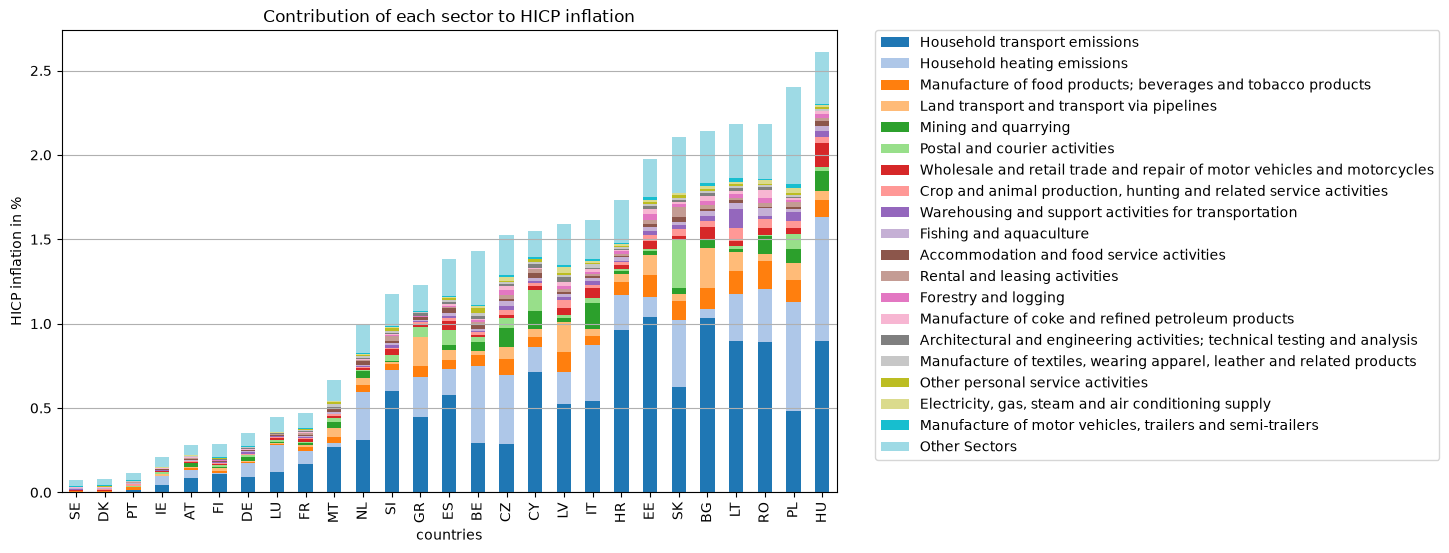

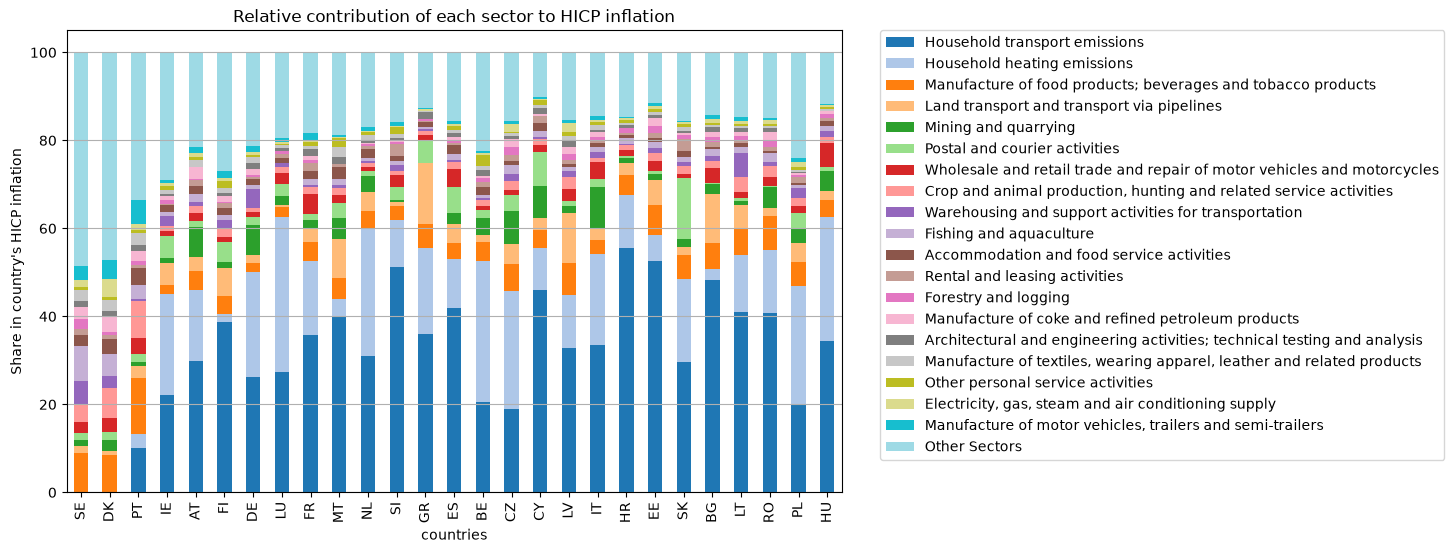

In [132]:
exposure_df = sectoral_rec.to_pandas()
exposure_df = exposure_df.transpose()
exposure_df["aggr_sectoral_exposure"] = exposure_df.sum(axis=1)
exposure_df = exposure_df.sort_values(by="aggr_sectoral_exposure", ascending=False)
top9 = exposure_df.head(19)
other = pd.DataFrame(exposure_df.iloc[19:].sum(axis=0)).transpose()
other.index = ["Other Sectors"]
exposure_df = pd.concat([top9, other])
exposure_df = exposure_df.drop(columns=["aggr_sectoral_exposure"])
exposure_df = exposure_df.transpose()
exposure_df["aggr_sectoral_exposure"] = exposure_df.sum(axis=1)
exposure_df = exposure_df.sort_values(by="aggr_sectoral_exposure", ascending=True)
normalized_exposure = exposure_df.div(exposure_df["aggr_sectoral_exposure"], axis=0) * 100  # Normalize to percentage
exposure_df = exposure_df.drop(columns=["aggr_sectoral_exposure"])


cmap = plt.get_cmap("tab20")
colors = [cmap(i) for i in range(exposure_df.shape[1])]

ax = exposure_df.plot(kind = "bar", stacked=True, figsize=(10, 6), color = colors)
ax.grid(axis='y')
plt.title("Contribution of each sector to HICP inflation")
plt.ylabel("HICP inflation in %")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.savefig(os.path.join(figure_path, "bar_hicp_by_country_sector.png"), bbox_inches='tight', dpi=300)
plt.show()

normalized_exposure = normalized_exposure.drop(columns=["aggr_sectoral_exposure"])
ax = normalized_exposure.plot(kind = "bar", stacked=True, figsize=(10, 6), color = colors)
ax.grid(axis='y')
plt.title("Relative contribution of each sector to HICP inflation")
plt.ylabel("Share in country's HICP inflation")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.savefig(os.path.join(figure_path, "bar_relative_hicp_by_country_sector.png"), bbox_inches='tight', dpi=300)
plt.show()

## Scatterplot

### Average emission intensity

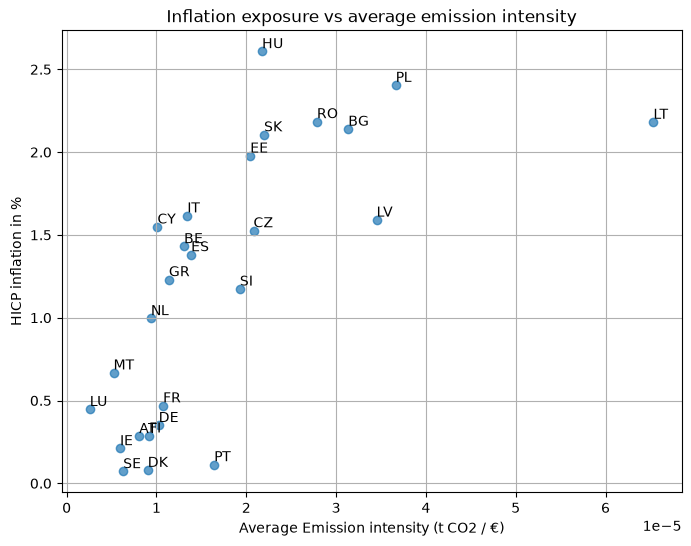

In [133]:
# scatter plot of exposure vs average emissions
plt.figure(figsize=(8, 6))
selection = df[df.index != "HR"] # Remove croatia because of the outlier (Eurostat data is likely wrong)
plt.scatter(selection["avg_Q"], selection["hicp_total"], alpha=0.7)
plt.title("Inflation exposure vs average emission intensity")
plt.xlabel("Average Emission intensity (t CO2 / €)")
plt.ylabel("HICP inflation in %")
plt.grid()
for country in selection.index:
    plt.annotate(country, (selection.loc[country]["avg_Q"], selection.loc[country]["hicp_total"]), fontsize=10, ha='left', va='bottom') 
plt.savefig(os.path.join(figure_path, "scatter_inflation_vs_emission_intensity.png"), bbox_inches='tight', dpi=300)
plt.show()

### Inflation exposure vs GDP per capita

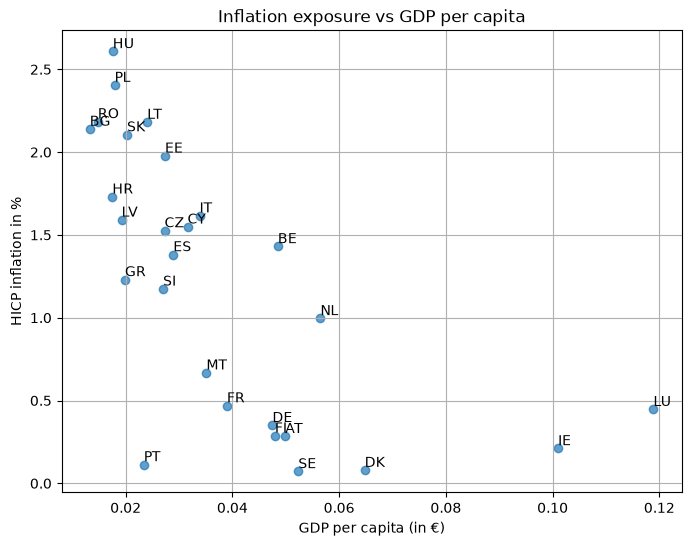

In [134]:
# plot inflation exposure vs GDP per capita
plt.figure(figsize=(8, 6))
plt.scatter(df["GDP_per_capita"], df["hicp_total"], alpha=0.7)
plt.title("Inflation exposure vs GDP per capita")
plt.xlabel("GDP per capita (in €)")
plt.ylabel("HICP inflation in %")
plt.grid()
for i, country in enumerate(df.index):
    plt.annotate(country, (df.loc[country]["GDP_per_capita"], df.loc[country]["hicp_total"]), fontsize=10, ha='left', va='bottom') 
plt.savefig(os.path.join(figure_path, "scatter_inflation_vs_gdp_per_capita.png"), bbox_inches='tight', dpi=300)
plt.show()

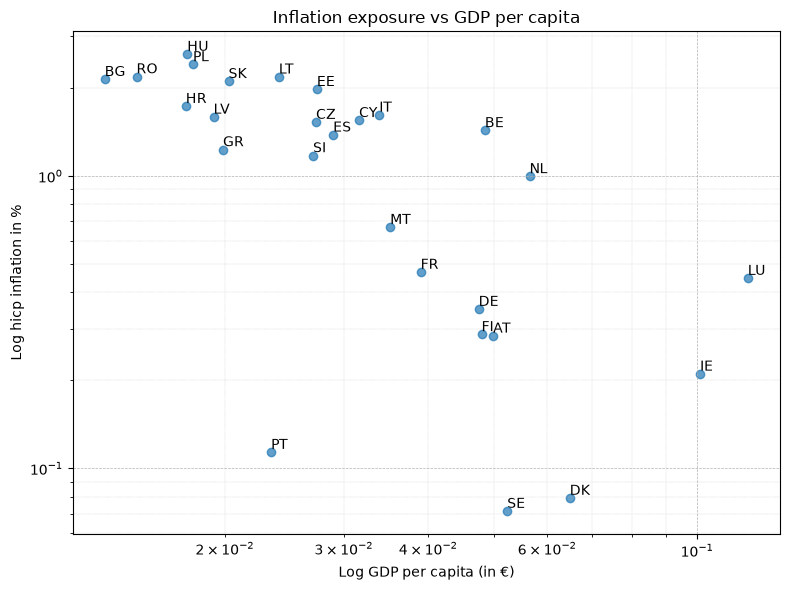

In [135]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(df["GDP_per_capita"], df["hicp_total"], alpha=0.7)

ax.set_title("Inflation exposure vs GDP per capita")
ax.set_xlabel("Log GDP per capita (in €)")
ax.set_ylabel("Log hicp inflation in %")

# Set log scales
ax.set_xscale('log')
ax.set_yscale('log')

# Grid (major + minor)
ax.grid(which='both', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle=':', linewidth=0.3)

# Annotate country names
for i, country in enumerate(df.index):
    plt.annotate(country, (df.loc[country]["GDP_per_capita"], df.loc[country]["hicp_total"]), fontsize=10, ha='left', va='bottom') 
    

plt.tight_layout()
plt.savefig(os.path.join(figure_path, "scatter_inflation_vs_gdp_per_capita_log.png"), bbox_inches='tight', dpi=300)
plt.show()


## Maps

### Map of inflation exposure

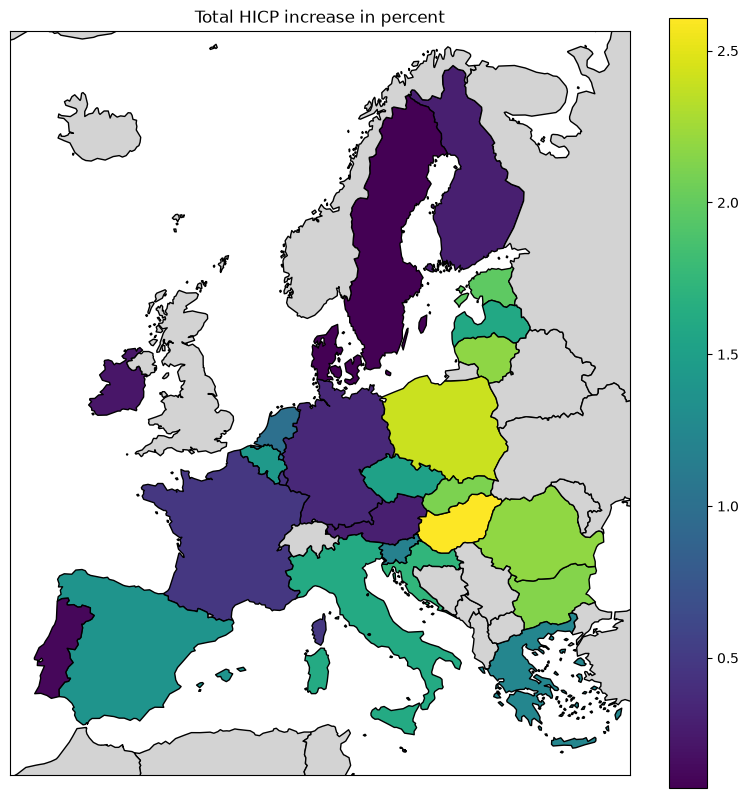

In [136]:
gdf = gpd.read_file("../data/geodata/CNTR_RG_20M_2024_3035.gpkg")
# rename EL to GR in the GeoDataFrame
gdf["CNTR_ID"] = gdf["CNTR_ID"].replace({"EL": "GR"})
gdf = gdf.merge(df, left_on="CNTR_ID", right_index=True, how="left")

ax = gdf.plot(column='hicp_total', 
              cmap='viridis',       
              legend=True,           
              figsize=(10, 10),
              missing_kwds={'color': 'lightgrey'},
              edgecolor='black')

# Set axis limits to only display the EU region
ax.set_xlim(2500000, 6000000)
ax.set_ylim(1300000, 5500000)
plt.title("Total HICP increase in percent")
ax.set_xticks([])
ax.set_yticks([])
plt.savefig(os.path.join(figure_path, "map_hicp.png"), bbox_inches='tight', dpi=300)
plt.show()

In [137]:
df["hicp_total"].sort_values(ascending=False)

HU    2.607715
PL    2.404480
RO    2.184912
LT    2.181345
BG    2.139255
SK    2.105540
EE    1.977260
HR    1.729998
IT    1.615920
LV    1.590655
CY    1.548427
CZ    1.526228
BE    1.430192
ES    1.381309
GR    1.230633
SI    1.173866
NL    0.995672
MT    0.667480
FR    0.468847
LU    0.446845
DE    0.350033
FI    0.286942
AT    0.283612
IE    0.210259
PT    0.113490
DK    0.079080
SE    0.071346
Name: hicp_total, dtype: float64

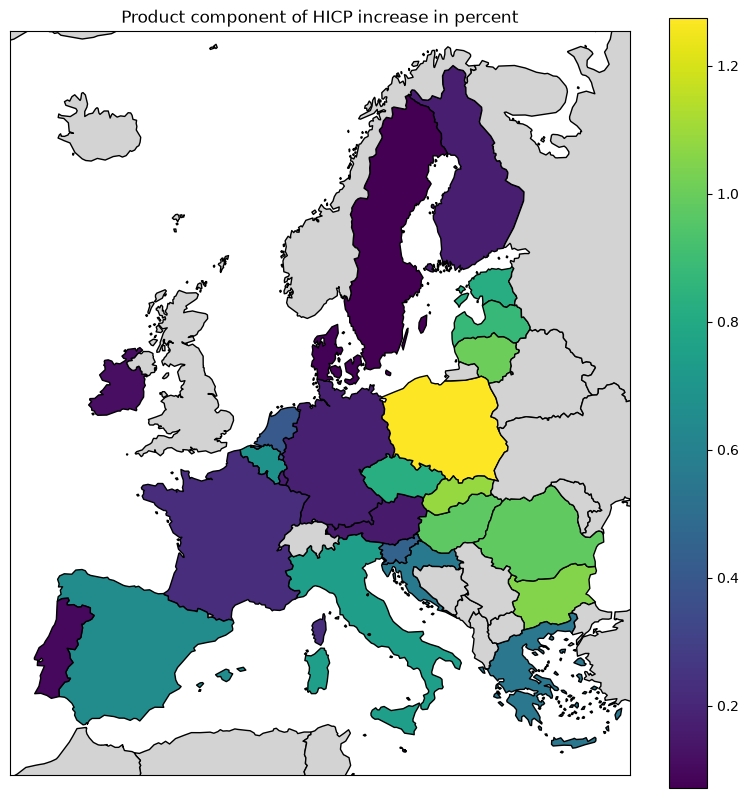

In [138]:
ax = gdf.plot(column='hicp_product', 
              cmap='viridis',       
              legend=True,           
              figsize=(10, 10),
              missing_kwds={'color': 'lightgrey'},
              edgecolor='black')

# Set axis limits to only display the EU region
ax.set_xlim(2500000, 6000000)
ax.set_ylim(1300000, 5500000)
plt.title("Product component of HICP increase in percent")
ax.set_xticks([])
ax.set_yticks([])
plt.savefig(os.path.join(figure_path, "map_hicp_product_component.png"), bbox_inches='tight', dpi=300)
plt.show()

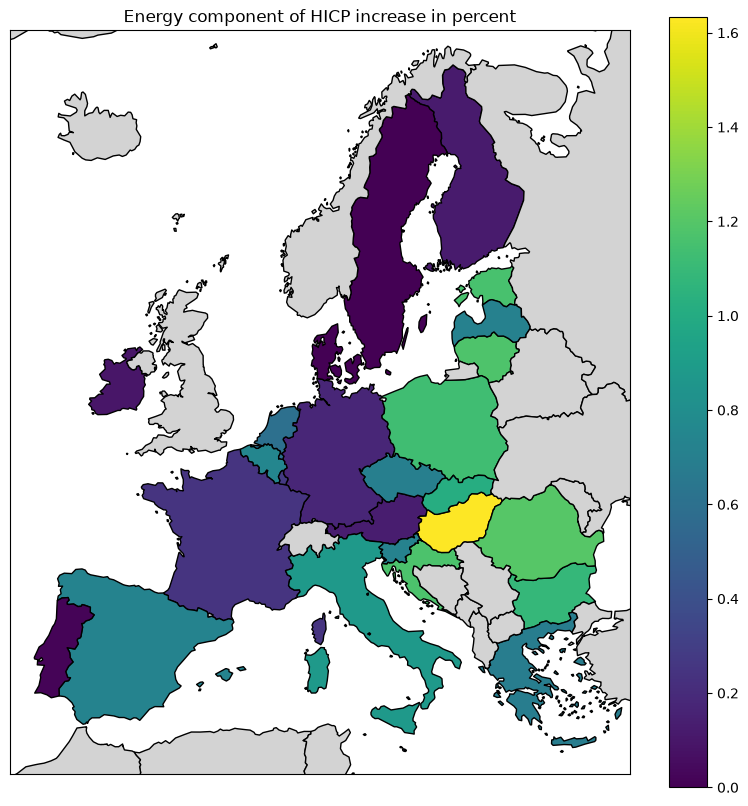

In [139]:
ax = gdf.plot(column='hicp_energy', 
              cmap='viridis',       
              legend=True,           
              figsize=(10, 10),
              missing_kwds={'color': 'lightgrey'},
              edgecolor='black')

# Set axis limits to only display the EU region
ax.set_xlim(2500000, 6000000)
ax.set_ylim(1300000, 5500000)
plt.title("Energy component of HICP increase in percent")
ax.set_xticks([])
ax.set_yticks([])
plt.savefig(os.path.join(figure_path, "map_hicp_energy_component.png"), bbox_inches='tight', dpi=300)
plt.show()

# How they voted
Compare country inflation with votes for ETS2 delay

In [140]:
VOTE_ID = 181375  # "Framework for achieving climate neutrality", 13 Nov 2025

url = f"https://howtheyvote.eu/api/votes/{VOTE_ID}/members.csv"
votes = pd.read_csv(url)

votes.head()

URLError: <urlopen error [Errno -3] Temporary failure in name resolution>

In [ ]:
# Outcome: FOR = 1, AGAINST = 0; exclude non-voters
reg_df = votes[votes["position"].isin(["VotePosition.FOR", "VotePosition.AGAINST"])].copy()
reg_df["vote_for"] = (reg_df["position"] == "VotePosition.FOR").astype(int)

# Add country-level inflation exposure
reg_df = reg_df.merge(
    df[["hicp_total"]].rename_axis("country").reset_index(),
    left_on="member.country.iso_alpha_2",
    right_on="country",
    how="left",
)

# Calculate Leave-One-Out (LOO) progressivity score per country
loo_scores = []

for country in countries:
    # Get all votes excluding the current country
    out_of_sample = reg_df[reg_df["member.country.iso_alpha_2"] != country]
    
    # Calculate average support rate for each party outside this country
    party_means = out_of_sample.groupby("member.group.short_label")["vote_for"].mean()
    
    # Get the current country's voting data
    in_sample = reg_df[reg_df["member.country.iso_alpha_2"] == country].copy()
    
    # Map the out-of-sample party scores to the current country's MEPs
    in_sample["expected_score"] = in_sample["member.group.short_label"].map(party_means)
    
    # Fallback: If a party only exists in this country, fill with the global mean
    global_mean = out_of_sample["vote_for"].mean()
    in_sample["expected_score"] = in_sample["expected_score"].fillna(global_mean)
    
    # The country's LOO score is the average of its MEPs' expected scores
    country_score = in_sample["expected_score"].mean()
    loo_scores.append({
        "member.country.iso_alpha_2": country, 
        "progressivity": country_score
    })

loo_df = pd.DataFrame(loo_scores)

# Merge the single LOO score into the regression data
reg_df = reg_df.merge(
    loo_df,
    on="member.country.iso_alpha_2",
    how="left",
)

# Drop NAs to ensure valid regression inputs
reg_df = reg_df.dropna(subset=["hicp_total", "progressivity", "vote_for"])

# Define X with the single composite party score and the hicp exposure 
regressors = sm.add_constant(reg_df[["hicp_total", "progressivity"]])
regressand = reg_df["vote_for"]

# Fit Logit model with clustered standard errors
model = sm.Logit(regressand, regressors).fit(
    disp=False,
    cov_type="cluster",
    cov_kwds={"groups": reg_df["member.country.iso_alpha_2"]},
)
print(model.summary())

# export regression results to LaTeX
with open(os.path.join(figure_path, "regression_results.tex"), "w") as f:
    f.write(model.summary().as_latex())

                           Logit Regression Results                           
Dep. Variable:               vote_for   No. Observations:                  627
Model:                          Logit   Df Residuals:                      624
Method:                           MLE   Df Model:                            2
Date:                 Fr, 11 Sep 2026   Pseudo R-squ.:                  0.1309
Time:                        13:58:42   Log-Likelihood:                -365.73
converged:                       True   LL-Null:                       -420.82
Covariance Type:              cluster   LLR p-value:                 1.188e-24
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.8685      1.100     -1.699      0.089      -4.024       0.287
hicp_total       -0.6806      0.364     -1.871      0.061      -1.393       0.032
progressivity     4.6232      1.584     

Even after controlling for a country's party composition, we see that a higher hicp inflation pressure reduces support for the EU's climate policies statistically significantly.

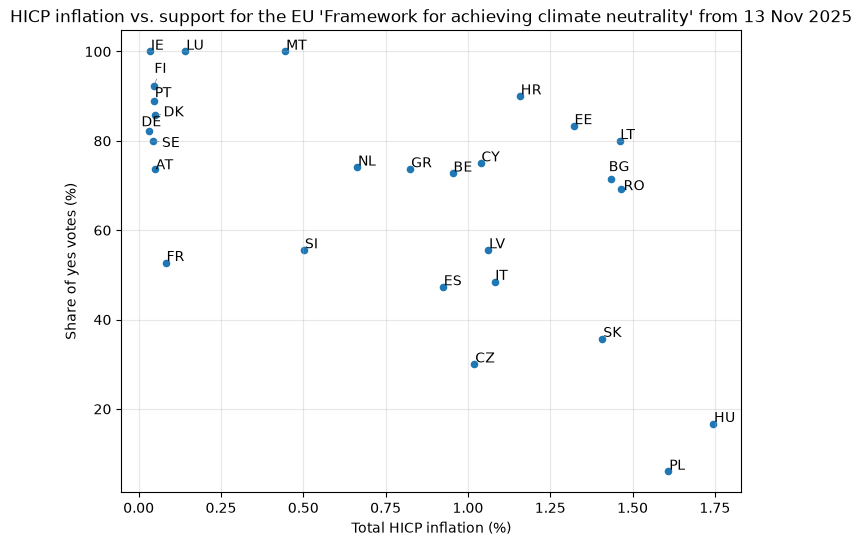

In [ ]:
# Calculate yes vote share in % and merge with inflation data
yes_share = reg_df.groupby("country")["vote_for"].mean() * 100
plot_df = df[["hicp_total"]].join(yes_share.rename("yes_share"))

# Create base scatter plot
ax = plot_df.plot.scatter(
    x="hicp_total", 
    y="yes_share", 
    figsize=(8, 6),
    title="HICP inflation vs. support for the EU 'Framework for achieving climate neutrality' from 13 Nov 2025",
    xlabel="Total HICP inflation (%)", 
    ylabel="Share of yes votes (%)"
)

#Collect all the text objects in a list (use ax.text instead of ax.annotate)
texts = []
for country, row in plot_df.iterrows():
    texts.append(ax.text(row["hicp_total"], row["yes_share"], country))

#Automatically adjust their positions to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

plt.grid(alpha=0.3)
plt.savefig(os.path.join(figure_path, "scatter_hicp_vs_yes_share.png"), bbox_inches='tight', dpi=300)
plt.show()

There is endogeneity however: Politicians who are against climate policies will also not build green infrastructure, which will then incentivize them to be more against climate policies, because the ETS would hit them harder. 

# Revenue Recycling: Social climate fund

The social climate fund will provide funding from 2028 to the end of 2032. Therefore, we have to distribute the total funds to 5 years in our calculations. Once prices increase, they will stay on an elevated **level** and households have to pay carbon taxes each year. So, as long as they don't decarbonize, they need financial support each year. 

Calculating the within country impact of the overall policy (ETS2 + SCF) is very difficult due to the following reasons:
- Different countries can and have establish different policies to use the funds. It seems 

## Analysis of already adopted Social Climate Plans
As of 05.09.2026, five countries have adopted concrete social climate plans: Greece, Latvia, Lithuania, Malta and Sweden. 

### [Greece](https://employment-social-affairs.ec.europa.eu/policies-and-activities/funding/social-climate-fund/social-climate-fund-national-plans/greeces-social-climate-plan_en)
- **Affected people**: 
  - 1.7 million households in energy poverty, 1.4 million transport uses in transport poverty.
  - They expect to "lift 460 000 vulnerable households and 300 000 vulnerable transport users out of energy or transport poverty". $\Rightarrow$ what happens with the rest?
- **Compensation housing costs**:
  -  2800 social housing units provide energy-efficient housing for 11500 beneficiaries. + Renovation of student residencies provide affordable housing for 5930 students (additionality??)
  - support for energy renovation of 62 000 dwellings and installation of 200 000 new heating systems (heat pumps or solar heating)
  - 9350 micro-enterprises supported in energy-efficiency upgrading
- **Compensation for transport costs**
  - New bus lines, transport on demand buses, trains. Also renovation of railway stations and metro stations to improve accessability for persons with disabilities (shouldn't this be financed from the national budget??)
  - 15 000 vehicles are leased to affected people. 15550 micro-enterprises are supported in purchasing electric vehicles.
  - subsidies for 13200 people with disabilities to purchase electric wheelchairs or scooters
- **Direct transfers**
  - None. General HICP increases are not offset
- **Interpretation**: 
  - Focus on direct costs, ignores indirect hicp increase
  - Only 24% of energy poverty and 21% of transport poverty will be addressed. 
  - Focus on reducing emission intensity through building renovations and new transport solutions. This is good, since it permanently reduces costs and doesn't subsidize fossil fuel companies. 

### Latvia
### Lithuania
### [Malta](https://employment-social-affairs.ec.europa.eu/policies-and-activities/funding/social-climate-fund/social-climate-fund-national-plans/maltas-social-climate-plan_en)
- **Affected people**: 
  - 43 301 energy-vulnerable households, 147 215 transport-vulnerable persons and 39 545 vulnerable micro-enterprises
  - 1 431 energy-vulnerable households of these will benefit from support. 30 000 users will benefit from community transport service. 865 micro-enterprices will be supportet
- **Compensation housing costs**:
  - 236 public apartments will be renovated. Additionally, 1431 public social housing apartments get heat pumps or solar panels.
- **Compensation for transport costs**
  - free on demand community transport services that are projected to reach 30 000 people
  - 865 micro-enterprises get support to cover the cost difference of an electric vehicle to an internal combustion engine vehicle. (Chinese EVs may already be cheaper!)
- **Direct transfers**
  - None
- **Interpretation**: 
  - Only 3% of energy-vulnerable households get support (Although it's unclear what this means. The report states that 'already 3747 live in energy poverty', so the threshold for vulnerability may be much lower than for energy poverty.)
  - 20% of transport poverty may be addressed 
### [Sweden](https://employment-social-affairs.ec.europa.eu/policies-and-activities/funding/social-climate-fund/social-climate-fund-national-plans/swedens-social-climate-plan_en)
- **Affected people**: 
  - 740 000 vulnerable transport users
  - 115 500 of these will benefit from support
- **Compensation housing costs**:
  - none
- **Compensation for transport costs**
  - 120€ monthly to buy or lease an electric car. Over three years max 6000€ per houeshold.
- **Direct transfers**
  - Only for "vulnerable transport users". General HICP increases are not offset
- **Interpretation**: 
  - Focus on direct costs, ignores indirect hicp increase (which is very small in Sweden though)
  - 16% of transport poverty will be addressed. 
  - The support doesn't seem large enough to buy an electric car. Which means that after 3 years, households have no electric car anymore while ETS prices continue to rise. 


In [ ]:
# pull number of households from eurostat
n_households = eurostat.get_data_df("lfst_hhnhtych")
n_households = n_households[(n_households["agechild"] == "TOTAL") & (n_households["phhcomp"] == "TOTAL") & (n_households["n_child"] == "TOTAL")]
n_households = n_households[["geo\\TIME_PERIOD", str(year)]]
n_households = n_households.rename(columns={"geo\\TIME_PERIOD": "geo", str(year): "n_households"})
#n_households["variable"] = "total"
n_households = n_households.replace({"EL": "GR"})
n_households.set_index("geo", inplace=True)
n_households = n_households[n_households.index.isin(countries)]
n_households
df = n_households.join(df, how="left")

In [ ]:
# pull share of households in energy poverty (as defined to keep home adequately warm)
epov_share = eurostat.get_data_df("ilc_mdes01")
epov_share = epov_share[(epov_share["hhcomp"] == "TOTAL") & (epov_share["rskpovth"] == "TOTAL")]
epov_share = epov_share[["geo\\TIME_PERIOD", str(year)]]
epov_share = epov_share.rename(columns={"geo\\TIME_PERIOD": "geo", str(year): "epov_share"})

epov_share = epov_share.replace({"EL": "GR"})
epov_share = epov_share.set_index("geo")
epov_share = epov_share[epov_share.index.isin(countries)]

df = epov_share.join(df, how="left")

df["n_households_in_energy_poverty"] = df["n_households"] * df["epov_share"] / 100


In [ ]:
df["n_households_in_energy_poverty"]

geo
AT     167.4640
BE     249.6480
BG     542.2790
CY      56.1662
CZ     222.9549
DE    2627.1063
DK     136.9016
EE      26.4600
GR     773.9460
ES    3413.3400
FI      79.6500
FR    3794.1720
HR      67.7074
HU     242.6100
IE     108.6624
IT    2262.0924
LT     299.8620
LU      10.2060
LV      43.2425
MT      18.3534
NL     613.0992
PL     513.8958
PT     702.3081
RO     817.1172
SE     197.1157
SI      28.5483
SK     143.3078
Name: n_households_in_energy_poverty, dtype: float64

In [ ]:
# Load country SCF allocations
scf_df = pd.read_excel("../data/social climate fund/SCF allocations.xlsx", sheet_name="direct payments")
# use country converter to map country names to ISO2 codes
scf_df["iso2_code"] = coco.convert(scf_df["country"].tolist(), to="ISO2")
scf_df = scf_df[scf_df["iso2_code"].isin(countries)]
scf_df.set_index("iso2_code", inplace=True)
scf_df

# merge on country index with df 
df = df.join(scf_df, how="left")
df

EU27 not found in regex


,epov_share,n_households,rec,rec_d,rec_i,hicp_heating,hicp_personal_transport,hicp_energy,hicp_product,hicp_product_d,...,GDP_per_capita,Q,q,csd_aggr,rec_aggr,n_households_in_energy_poverty,country,allocation_start_2028,plus_25_percent_per_country,maximum_direct_payments
geo,,,,,,,,,,,,,,,,,,,,,
AT,4.0,4186.6,1.271962,0.000000,1.271962,0.000000,0.000000,0.000000,0.048891,0.000000,...,0.049895,7.576393e+12,array*sel_{a.name}*{self.name}/array Part obje...,0.000000,0.019874,167.4640,Austria,5.061186e+08,6.748247e+08,2.530593e+08
BE,4.8,5201.0,10.999196,7.147391,3.851806,0.307879,0.196589,0.504467,0.448667,0.274330,...,0.048522,1.687928e+13,array*sel_{a.name}*{self.name}/array Part obje...,0.168505,0.171862,249.6480,Belgium,1.450864e+09,1.934485e+09,7.254319e+08
BG,19.0,2854.1,14.109094,7.161883,6.947211,0.034866,0.694638,0.729505,0.704049,0.363891,...,0.013279,6.264446e+12,array*sel_{a.name}*{self.name}/array Part obje...,0.221954,0.220455,542.2790,Bulgaria,2.185109e+09,2.913478e+09,1.092554e+09
CY,14.6,384.7,10.484616,7.431792,3.052824,0.099133,0.478551,0.577684,0.460496,0.308313,...,0.031596,7.226744e+11,array*sel_{a.name}*{self.name}/array Part obje...,0.150548,0.163822,56.1662,Cyprus,1.147027e+08,1.529369e+08,5.735133e+07
CZ,4.9,4550.1,13.808206,7.261385,6.546821,0.275213,0.193838,0.469051,0.550180,0.250265,...,0.027288,1.468653e+13,array*sel_{a.name}*{self.name}/array Part obje...,0.226562,0.215753,222.9549,Czechia,1.366074e+09,1.821432e+09,6.830371e+08
DE,6.3,41700.1,0.700702,0.000000,0.700702,0.000000,0.000000,0.000000,0.032508,0.000000,...,0.047501,8.394556e+13,array*sel_{a.name}*{self.name}/array Part obje...,0.000000,0.010948,2627.1063,Germany,4.648917e+09,6.198556e+09,2.324459e+09
DK,4.4,3111.4,1.013443,0.000000,1.013443,0.000000,0.000000,0.000000,0.048221,0.000000,...,0.064795,6.448821e+12,array*sel_{a.name}*{self.name}/array Part obje...,0.000000,0.015835,136.9016,Denmark,2.841145e+08,3.788193e+08,1.420572e+08
EE,3.6,735.0,11.393412,5.312059,6.081353,0.078769,0.698957,0.777726,0.543189,0.250932,...,0.027364,1.601532e+12,array*sel_{a.name}*{self.name}/array Part obje...,0.143714,0.178022,26.4600,Estonia,1.628190e+08,2.170921e+08,8.140952e+07
GR,19.0,4073.4,7.183451,3.658957,3.524494,0.161147,0.298061,0.459207,0.365327,0.208533,...,0.019872,4.706279e+12,array*sel_{a.name}*{self.name}/array Part obje...,0.109811,0.112241,773.9460,Greece,3.135696e+09,4.180929e+09,1.567848e+09


In [ ]:
# per-household SCF transfer
# df["allocation_per_hh"] = df["plus_25_percent_per_country"] / df["n_households"]
# df["allocation_per_hh"] = df["allocation_start_2028"] / df["n_households"]
#df["allocation_per_hh"] = df["maximum_direct_payments"] / df["n_households_in_energy_poverty"]
df["allocation_per_hh"] = df["maximum_direct_payments"] / df["n_households"]

# per-household annual cost increase caused by ETS2's contribution to HICP inflation
df["cost_increase_per_hh"] = (df["hicp_total"] / 100) * (df["final_demand"] / df["n_households"])

# costs per household over four years (2028-2032)
df["cost_increase_per_hh_5y"] = df["cost_increase_per_hh"] * 5

# offset ratio: >1 means SCF more than covers the ETS2-driven cost increase, <1 means partial coverage
df["scf_offset_ratio"] = df["allocation_per_hh"] / df["cost_increase_per_hh_5y"]
df["scf_offset_ratio"] = df["scf_offset_ratio"].replace([np.inf, -np.inf], np.nan).fillna(0)

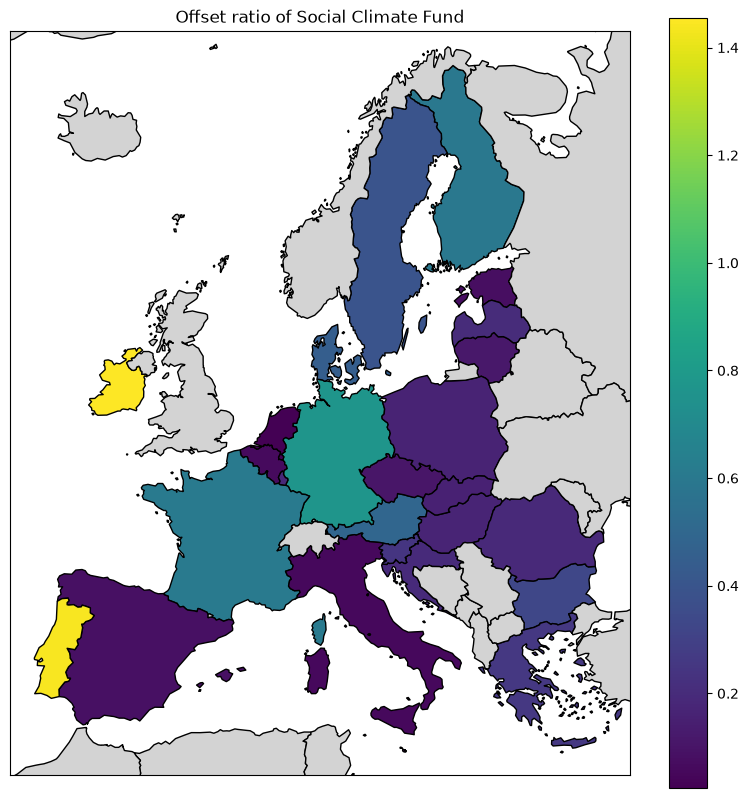

In [ ]:
gdf = gpd.read_file("../data/geodata/CNTR_RG_20M_2024_3035.gpkg")
# rename EL to GR in the GeoDataFrame
gdf["CNTR_ID"] = gdf["CNTR_ID"].replace({"EL": "GR"})
gdf = gdf.merge(df, left_on="CNTR_ID", right_index=True, how="left")

ax = gdf.plot(column='scf_offset_ratio', 
              cmap='viridis',      
              legend=True,           
              figsize=(10, 10),
              missing_kwds={'color': 'lightgrey'},
              edgecolor='black')

# Set axis limits to only display the EU region
ax.set_xlim(2500000, 6000000)
ax.set_ylim(1300000, 5500000)
plt.title("Offset ratio of Social Climate Fund")
ax.set_xticks([])
ax.set_yticks([])
plt.savefig(os.path.join(figure_path, "map_offset_ratio.png"), bbox_inches='tight', dpi=300)
plt.show()

TODOs: 
- plot countries as bar plots
- Check the numbers of the offset plan: We probably want to calculate the allocations ourselves, based on the the carbon prices (note, not the carbon price changes!) and the total emissions, which will thus give us the revenue? And there is also some fixed amount financed besides the ETS2 revenue?

- Interpretation: Right now every country benefits and Bulgaria especially benefits - have they calculated Bulgarias ETS2 exposure so much different than we did? If you take the EC scenario with unequal price changes, Bulgaria no longer profits that much.

In [ ]:
total_cost_increase = ((df["hicp_total"] / 100) * (df["final_demand"])).sum() * 5
total_direct_payments = df["maximum_direct_payments"].sum()
avg_offset_ratio = total_direct_payments / total_cost_increase

avg_offset_ratio


np.float64(0.13510358521339608)

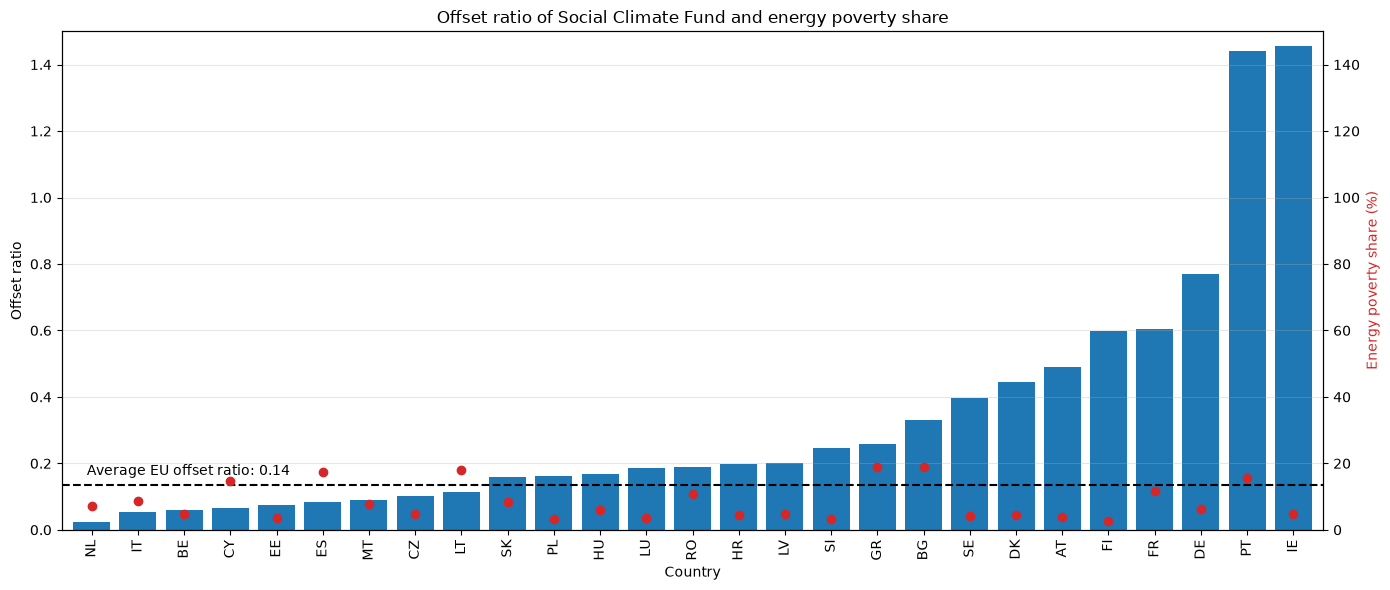

,scf_offset_ratio
geo,
NL,0.024152
IT,0.053939
BE,0.058506
CY,0.065240
EE,0.075313
ES,0.082929
MT,0.088422
CZ,0.102478
LT,0.113897


In [ ]:

plot_df = df.sort_values(by = "scf_offset_ratio")[["scf_offset_ratio", "epov_share"]].copy()
plot_df["epov_share"] = plot_df["epov_share"]

ax = plot_df["scf_offset_ratio"].plot(
    kind="bar",
    figsize=(14, 6),
    width=0.8,
    legend=False
)

ax.set_xlabel("Country")
ax.set_ylabel("Offset ratio")
ax.set_title("Offset ratio of Social Climate Fund and energy poverty share")
ax.grid(axis="y", alpha=0.3)
ax.set_ylim([0, 1.5])
ax.axhline(y=avg_offset_ratio, color='#000000', linestyle='--', label=f'Average offset ratio: {avg_offset_ratio:.2f}')
ax.text(0.02, avg_offset_ratio + 0.02, f'Average EU offset ratio: {avg_offset_ratio:.2f}', color='#000000', fontsize=10, ha='left', va='bottom', transform=ax.get_yaxis_transform())

ax2 = ax.twinx()
ax2.scatter(range(len(plot_df)), plot_df['epov_share'], color='tab:red', zorder=3)
ax2.set_ylabel('Energy poverty share (%)', color='tab:red')
ax2.set_ylim([0, 150])



plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(figure_path, "bar_scf_offset_ratio_by_country.png"), bbox_inches='tight', dpi=300)
plt.show()




df.sort_values(by = "scf_offset_ratio")[["scf_offset_ratio"]]
